### Ячейка 1: Импорты

In [12]:
# Ячейка 1: Импорты (ИСПРАВЛЕНО - формат логов)

# --- Основные Библиотеки ---
import os
import random
import logging
import warnings
import datetime
import traceback
import pprint
import time
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Tuple, Dict, Any, Optional

# --- Математика и Данные ---
import numpy as np
import pandas as pd
from scipy import stats # Для расчета наклона

# --- PyTorch ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torch.optim.lr_scheduler import OneCycleLR, ReduceLROnPlateau, _LRScheduler
from torch.cuda.amp import GradScaler, autocast

# --- ML Утилиты ---
from sklearn.model_selection import train_test_split
import Levenshtein # Для метрики

# --- Конфигурация и HPO ---
import hydra
from omegaconf import DictConfig, OmegaConf, MISSING
import optuna
# from optuna.pruners import HyperbandPruner

# --- Визуализация и Прогресс ---
from tqdm.notebook import tqdm # Используем tqdm.notebook для Jupyter
import matplotlib.pyplot as plt

# --- Настройка Логирования (УПРОЩЕННЫЙ ФОРМАТ) ---
log_formatter = logging.Formatter('%(message)s') # <--- Только сообщение
log_handler = logging.StreamHandler()
log_handler.setFormatter(log_formatter)

log = logging.getLogger(__name__)
log.setLevel(logging.INFO)
if log.hasHandlers():
    log.handlers.clear()
log.addHandler(log_handler)
log.propagate = False

logging.getLogger("optuna").setLevel(logging.WARNING)
logging.getLogger("hydra").setLevel(logging.WARNING)

# --- Подавление Предупреждений ---
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# --- Определение Устройства ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
log.info(f"Используемое устройство: {DEVICE}")

# --- Установка Сида ---
def set_seed(seed_value: int):
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_value)

set_seed(42)

log.info("Логирование настроено (только сообщения).")

Используемое устройство: cuda
Логирование настроено (только сообщения).


### Ячейка 2: Конфигурация с Hydra (Dataclasses)

In [13]:
# --- НОВЫЙ Dataclass для Аугментаций ---
@dataclass
class AugmentationParams:
    enable: bool = False               # Включить аугментации?
    noise_level: float = 0.0           # Уровень Гауссова шума (std dev), 0 = выкл
    time_mask_prob: float = 0.0        # Вероятность применения Time Masking
    time_mask_max_width: int = 40      # Макс. ширина маски времени (в шагах)
    channel_mask_prob: float = 0.0     # Вероятность применения Channel Masking
    channel_mask_max_channels: int = 3 # Макс. кол-во маскируемых каналов
    gain_prob: float = 0.0             # Вероятность изменения усиления
    gain_range: Tuple[float, float] = field(default_factory=lambda: (0.8, 1.2)) # Диапазон множителя усиления

# --- ОБНОВЛЕННЫЕ Dataclasses ---

@dataclass
class PathsConfig:
    data_dir: str = MISSING
    feature_dir: str = MISSING

@dataclass
class DataParamsConfig:
    metadata_filename: str = "train.csv"
    label_column: str = "message"
    feature_input_channels: int = 16
    feature_seq_len: int = 1600
    num_bandwidth_groups: int = 4
    train_val_split_ratio: float = 0.1
    random_seed: int = 42
    blank_char: str = "<blank>"
    allowed_chars: str = " #АБВГДЕЖЗИЙКЛМНОПРСТУФХЦЧШЩЪЫЬЭЮЯ0123456789"
    dataset_fraction: float = 1.0

@dataclass
class ModelParamsConfig:
    block_out_channels: List[int] = field(default_factory=lambda: [64, 128])
    block_kernel_size_0: int = 5
    block_kernel_size_1: int = 3
    block_stride_0: int = 2
    block_stride_1: int = 2
    activation_type: str = 'GELU'

    # --- НОВЫЕ Параметры Модели ---
    use_se: bool = True                # Использовать SE-блоки в ResNet?
    se_reduction_ratio: int = 4        # Фактор сжатия в SE-блоках
    use_depthwise: bool = False        # Использовать Depthwise Separable Conv?

    # Параметры RNN (без изменений)
    rnn_type: str = 'GRU'
    rnn_hidden_size: int = 256
    rnn_num_layers: int = 2
    rnn_dropout: float = 0.2

    # Параметры Классификатора (без изменений)
    classifier_dropout: float = 0.2
    vocab_size: Optional[int] = None

@dataclass
class TrainParamsConfig:
    batch_size: int = 32
    num_epochs: int = 50
    learning_rate: float = 1e-4
    max_lr: float = 3e-4
    optimizer: str = 'AdamW'
    scheduler: Optional[str] = 'OneCycleLR'
    scheduler_reduce_factor: float = 0.1
    scheduler_patience: int = 5
    weight_decay: float = 1e-4
    use_amp: bool = True
    early_stopping_patience: int = 10
    max_grad_norm: Optional[float] = 1.0
    levenshtein_slope_percentage: float = 0.4

    # --- НОВОЕ: Вложенная конфигурация аугментаций ---
    augmentations: AugmentationParams = field(default_factory=AugmentationParams)

@dataclass
class HPOParamsConfig:
    n_trials: int = 50
    storage_name: Optional[str] = None
    study_name: Optional[str] = None
    metric_to_optimize: str = "val_levenshtein"
    direction: str = "minimize"
    param_distributions: Dict[str, Any] = field(default_factory=dict)

@dataclass
class Config:
    defaults: List[Any] = field(default_factory=lambda: [
        "_self_",
        {"override hydra/hydra_logging": "disabled"},
        {"override hydra/job_logging": "disabled"},
    ])
    paths: PathsConfig = field(default_factory=PathsConfig)
    data_params: DataParamsConfig = field(default_factory=DataParamsConfig)
    model_params: ModelParamsConfig = field(default_factory=ModelParamsConfig) # Теперь с use_se, use_depthwise
    train_params: TrainParamsConfig = field(default_factory=TrainParamsConfig) # Теперь с augmentations
    hpo_params: HPOParamsConfig = field(default_factory=HPOParamsConfig)

    enable_hpo: bool = False
    finetune_checkpoint_path: Optional[str] = None
    run_timestamp: Optional[str] = None

# --- Регистрация конфига в Hydra ---
cs = hydra.core.config_store.ConfigStore.instance()
cs.store(name="base_config", node=Config)

log.info("Конфигурационные классы обновлены (SE, Depthwise, Augmentations).")

Конфигурационные классы обновлены (SE, Depthwise, Augmentations).


### Ячейка 3: Функции Загрузки и Предобработки Данных

In [14]:
def load_metadata(data_dir: Path, cfg: DictConfig) -> pd.DataFrame:
    """Загружает и минимально обрабатывает метаданные."""
    filename = cfg.data_params.metadata_filename
    label_col = cfg.data_params.label_column
    filepath = data_dir / filename
    if not filepath.exists():
        log.error(f"🛑 Ошибка: Файл метаданных не найден: {filepath}")
        raise FileNotFoundError(f"Файл метаданных не найден: {filepath}")

    try:
        df = pd.read_csv(filepath)
    except Exception as e:
        log.error(f"🛑 Ошибка чтения CSV файла '{filepath}': {e}")
        raise

    if label_col not in df.columns:
        log.error(f"🛑 Ошибка: Колонка с метками '{label_col}' не найдена в {filepath}. Доступные колонки: {df.columns.tolist()}")
        raise KeyError(f"Колонка с метками '{label_col}' не найдена.")

    # Предобработка меток
    df = df.dropna(subset=[label_col]) # Удаляем строки без метки
    df[label_col] = df[label_col].astype(str).str.upper().str.strip()
    df = df[df[label_col].str.len() > 0] # Удаляем строки с пустыми метками после обработки

    log.info(f"Метаданные загружены из '{filename}'. Найдено {len(df)} записей после очистки.")
    return df

def create_vocabulary(df: pd.DataFrame, cfg: DictConfig) -> Tuple[Dict[str, int], Dict[int, str], int]:
    """Создает словарь символов на основе разрешенных символов."""
    labels = df[cfg.data_params.label_column]
    allowed_chars = cfg.data_params.allowed_chars
    blank_char = cfg.data_params.blank_char

    # Проверяем наличие символа решетки '#' в allowed_chars из конфига
    if '#' not in allowed_chars:
         log.warning("⚠️ Символ '#' не найден в data_params.allowed_chars. Убедитесь, что это ожидаемо.")

    unique_chars_allowed = set(allowed_chars)
    all_data_chars = set("".join(labels.tolist()))
    unknown_chars = all_data_chars - unique_chars_allowed

    if unknown_chars:
        log.warning(f"⚠️ ВНИМАНИЕ: Найдены символы в метках, отсутствующие в 'allowed_chars': {unknown_chars}. Они будут ИГНОРИРОВАНЫ при кодировании и фильтрации данных!")

    # Создаем словарь только из разрешенных символов + blank
    char_list = sorted(list(unique_chars_allowed))
    if blank_char in char_list:
        log.warning(f"⚠️ Символ бланка '{blank_char}' уже присутствует в 'allowed_chars'. Он будет использован как обычный символ.")
        # Не добавляем его снова
    else:
        char_list.append(blank_char)

    char2idx = {char: idx for idx, char in enumerate(char_list)}
    idx2char = {idx: char for idx, char in enumerate(char_list)}
    vocab_size = len(char_list)

    if cfg.data_params.blank_char not in char2idx:
        log.error(f"🛑 КРИТИЧЕСКАЯ ОШИБКА: Символ бланка '{cfg.data_params.blank_char}' не попал в словарь! Проверьте 'allowed_chars'.")
        raise ValueError("Символ бланка не найден в словаре.")

    log.info(f"Словарь создан: {vocab_size} символов (включая бланк '{blank_char}' на индексе {char2idx[blank_char]}).")
    return char2idx, idx2char, vocab_size

def split_data(df: pd.DataFrame, test_size: float, random_state: int) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Разделяет DataFrame на обучающую и валидационную выборки."""
    if not (0 <= test_size < 1):
        log.error(f"🛑 Ошибка: train_val_split_ratio ({test_size}) должен быть >= 0 и < 1.")
        raise ValueError("train_val_split_ratio должен быть >= 0 и < 1.")

    if test_size == 0:
        log.info("Разделение не требуется (test_size=0). Вся выборка используется для обучения.")
        return df.copy(), pd.DataFrame(columns=df.columns) # Возвращаем пустой DataFrame для val
    else:
        train_df, val_df = train_test_split(df, test_size=test_size, random_state=random_state, shuffle=True)
        log.info(f"Данные разделены: Обучение={len(train_df)}, Валидация={len(val_df)} (Доля валидации: {test_size:.2f})")
        return train_df, val_df

### Ячейка 4: Класс Dataset

In [15]:
# --- Функции для Аугментаций ---

def add_gaussian_noise(features: np.ndarray, noise_level: float) -> np.ndarray:
    """Добавляет Гауссов шум."""
    if noise_level > 0:
        noise = np.random.normal(0, noise_level, features.shape).astype(np.float32)
        return features + noise
    return features

def apply_time_mask(features: np.ndarray, max_width: int) -> np.ndarray:
    """Применяет маску по времени (вертикальная полоса)."""
    num_channels, seq_len = features.shape
    if max_width <= 0 or max_width >= seq_len:
        return features
    width = random.randint(1, max_width)
    start = random.randint(0, seq_len - width)
    features[:, start : start + width] = 0
    return features

def apply_channel_mask(features: np.ndarray, max_channels: int) -> np.ndarray:
    """Применяет маску по каналам (горизонтальная полоса)."""
    num_channels, seq_len = features.shape
    if max_channels <= 0 or max_channels >= num_channels:
        return features
    count = random.randint(1, max_channels)
    # Выбираем 'count' случайных каналов без повторений
    channels_to_mask = random.sample(range(num_channels), count)
    features[channels_to_mask, :] = 0
    return features

def apply_gain(features: np.ndarray, gain_range: Tuple[float, float]) -> np.ndarray:
    """Применяет случайное изменение усиления."""
    min_gain, max_gain = gain_range
    if min_gain >= max_gain:
        return features
    gain = random.uniform(min_gain, max_gain)
    return features * gain

# --- Обновленный Класс Dataset ---
class MorseDataset(Dataset):
    """
    Класс Dataset для загрузки признаков (.npy) и текстовых меток.
    Применяет аугментации к обучающим данным.
    """
    def __init__(self, df: pd.DataFrame, feature_dir: Path, char2idx: Dict[str, int],
                 cfg: DictConfig, is_train: bool): # <-- Добавлен флаг is_train
        self.df_orig = df.copy()
        self.feature_dir = feature_dir
        self.char2idx = char2idx
        self.seq_len = cfg.data_params.feature_seq_len
        self.label_column = cfg.data_params.label_column
        self.blank_char_idx = char2idx.get(cfg.data_params.blank_char, -1)
        self.is_train = is_train # <-- Сохраняем флаг
        self.aug_cfg = cfg.train_params.augmentations # <-- Получаем конфиг аугментаций

        # --- Проверки и фильтрация (без изменений) ---
        if self.label_column not in df.columns:
             log.error(f"🛑 Dataset: Колонка '{self.label_column}' не найдена.")
             self.df = pd.DataFrame(columns=['id', self.label_column])
             return
        if 'id' not in df.columns:
            log.error(f"🛑 Dataset: Колонка 'id' не найдена.")
            self.df = pd.DataFrame(columns=['id', self.label_column])
            return
        original_len = len(self.df_orig)
        self.df = self.df_orig[
            self.df_orig[self.label_column].apply(lambda text: all(c in self.char2idx for c in str(text)))
        ].copy()
        filtered_len = len(self.df)
        if original_len > filtered_len:
             log.warning(f"⚠️ Dataset ({'Train' if is_train else 'Val'}): Отфильтровано {original_len - filtered_len} сэмплов из-за неизвестных символов.")
        if filtered_len == 0 and original_len > 0:
             log.error(f"🛑 Dataset ({'Train' if is_train else 'Val'}): Все сэмплы отфильтрованы!")
        elif filtered_len > 0:
             log_level = logging.DEBUG if filtered_len == original_len else logging.INFO
             log.log(log_level, f"Dataset ({'Train' if is_train else 'Val'}) инициализирован: {filtered_len} валидных сэмплов.")
        self.df = self.df.reset_index(drop=True)
        # Логируем параметры аугментации один раз при создании обучающего датасета
        if self.is_train and self.aug_cfg.enable:
            log.info("--- Параметры Аугментации (Train) ---")
            log.info(f"  Шум: {self.aug_cfg.noise_level > 0} (Уровень: {self.aug_cfg.noise_level:.2f})")
            log.info(f"  Маска Времени: {self.aug_cfg.time_mask_prob > 0} (Prob: {self.aug_cfg.time_mask_prob:.2f}, Width: {self.aug_cfg.time_mask_max_width})")
            log.info(f"  Маска Каналов: {self.aug_cfg.channel_mask_prob > 0} (Prob: {self.aug_cfg.channel_mask_prob:.2f}, Count: {self.aug_cfg.channel_mask_max_channels})")
            log.info(f"  Усиление: {self.aug_cfg.gain_prob > 0} (Prob: {self.aug_cfg.gain_prob:.2f}, Range: {self.aug_cfg.gain_range})")
            log.info("------------------------------------")


    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        if not (0 <= idx < len(self.df)):
             log.error(f"🛑 Dataset: Запрошен некорректный индекс {idx}")
             return torch.empty(0), torch.empty(0)

        sample = self.df.iloc[idx]
        filename_raw = sample.get('id')
        label_text = str(sample[self.label_column])
        base_filename = str(filename_raw).split('.')[0]
        feature_path = self.feature_dir / f"{base_filename}.npy"

        try:
            features = np.load(feature_path).astype(np.float32)

            if features.ndim != 2:
                log.warning(f"⚠️ Dataset: Неожиданная размерность ({features.ndim}D) в {feature_path}. Пропуск.")
                return torch.empty(0), torch.empty(0)

            # Padding / Truncation (без изменений)
            current_len = features.shape[1]
            if current_len != self.seq_len:
                 if current_len < self.seq_len:
                     padding = np.zeros((features.shape[0], self.seq_len - current_len), dtype=np.float32)
                     features = np.concatenate((features, padding), axis=1)
                 else:
                     features = features[:, :self.seq_len]

            # --- ПРИМЕНЕНИЕ АУГМЕНТАЦИЙ (только для train) ---
            if self.is_train and self.aug_cfg.enable:
                # Шум
                features = add_gaussian_noise(features, self.aug_cfg.noise_level)
                # Маска времени
                if random.random() < self.aug_cfg.time_mask_prob:
                    features = apply_time_mask(features, self.aug_cfg.time_mask_max_width)
                # Маска каналов
                if random.random() < self.aug_cfg.channel_mask_prob:
                    features = apply_channel_mask(features, self.aug_cfg.channel_mask_max_channels)
                # Изменение усиления
                if random.random() < self.aug_cfg.gain_prob:
                    features = apply_gain(features, self.aug_cfg.gain_range)
            # --- Конец Аугментаций ---

            features_tensor = torch.from_numpy(features)

            # Кодирование метки (без изменений)
            label_indices = [self.char2idx[char] for char in label_text]
            label_tensor = torch.tensor(label_indices, dtype=torch.long)

            return features_tensor, label_tensor

        except FileNotFoundError:
            log.error(f"🛑 Dataset: Файл не найден: {feature_path}. Пропуск.")
            return torch.empty(0), torch.empty(0)
        except Exception as e:
            log.error(f"🛑 Dataset: Ошибка обработки {idx} (файл: {base_filename}): {e}", exc_info=True)
            return torch.empty(0), torch.empty(0)

log.info("Класс MorseDataset обновлен (добавлены аугментации).")

Класс MorseDataset обновлен (добавлены аугментации).


### Ячейка 5: Функция collate_fn

In [16]:
def collate_fn(batch: List[Tuple[torch.Tensor, torch.Tensor]], blank_idx: int) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Собирает батч из отдельных сэмплов (признаки, метки).
    Отфильтровывает "пустые" сэмплы, возникшие из-за ошибок в Dataset.
    Применяет padding к меткам.
    Возвращает тензоры признаков, меток и их длин.
    """
    # 1. Фильтруем некорректные сэмплы (пустые тензоры из Dataset)
    valid_batch = [item for item in batch if item[0].numel() > 0 and item[1].numel() > 0]

    # 2. Если весь батч оказался невалидным
    if not valid_batch:
        # Возвращаем пустые тензоры с правильными типами, чтобы избежать ошибок дальше
        return (torch.empty(0, dtype=torch.float), torch.empty(0, dtype=torch.long),
                torch.empty(0, dtype=torch.long), torch.empty(0, dtype=torch.long))

    # 3. Разделяем признаки и метки
    features = [item[0] for item in valid_batch] # List[Tensor(C, L)]
    labels = [item[1] for item in valid_batch]   # List[Tensor(Target_L)]

    # 4. Стэкинг признаков (они уже имеют одинаковую длину L из Dataset)
    # Превращаем List[Tensor(C, L)] в Tensor(B, C, L)
    features_stacked = torch.stack(features, dim=0)

    # 5. Создаем тензор длин признаков (все они равны L после обработки в Dataset)
    # Длина нужна для CTC loss (хотя мы ее пересчитаем после CNN)
    # Tensor(B)
    feature_lengths = torch.full((len(valid_batch),), features_stacked.shape[2], dtype=torch.long)

    # 6. Padding меток
    # pad_sequence ожидает List[Tensor(Target_L)]
    # Возвращает Tensor(B, Max_Target_L)
    labels_padded = pad_sequence(labels, batch_first=True, padding_value=float(blank_idx)) # Используем float для pad_sequence

    # 7. Создаем тензор реальных длин меток (до padding'а)
    # Tensor(B)
    label_lengths = torch.tensor([len(lab) for lab in labels], dtype=torch.long)

    return features_stacked, labels_padded.long(), feature_lengths, label_lengths # Возвращаем labels_padded как long

### Ячейка 6: Архитектура Модели (CRNN)

In [17]:
# Ячейка 6: Архитектура Модели (SE, Depthwise) - ИСПРАВЛЕНО (get_activation)

# --- Вспомогательная функция для получения активации ---
def get_activation(activation_type: str) -> nn.Module:
    """Возвращает слой активации по имени."""
    if activation_type.lower() == 'relu':
        return nn.ReLU(inplace=True)
    elif activation_type.lower() == 'gelu':
        return nn.GELU()
    # Добавьте другие активации при необходимости
    else:
        log.warning(f"Неизвестный тип активации '{activation_type}'. Используется GELU.")
        return nn.GELU()

# --- Вспомогательные классы для Архитектуры ---

class SEBlock1D(nn.Module):
    """Squeeze-and-Excitation блок для 1D."""
    def __init__(self, channels: int, reduction_ratio: int = 4):
        super().__init__()
        reduced_channels = max(1, channels // reduction_ratio) # Гарантируем хотя бы 1 канал
        self.squeeze = nn.AdaptiveAvgPool1d(1)
        self.excitation = nn.Sequential(
            nn.Linear(channels, reduced_channels, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(reduced_channels, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, c, _ = x.size()
        y = self.squeeze(x).view(b, c)
        y = self.excitation(y).view(b, c, 1)
        return x * y.expand_as(x)

class DepthwiseSeparableConv1d(nn.Module):
    """Depthwise Separable Convolution для 1D."""
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int,
                 stride: int = 1, padding: int = 0, groups: int = 1, bias: bool = False):
        super().__init__()
        self.depthwise = nn.Conv1d(in_channels, in_channels, kernel_size, stride, padding,
                                   groups=in_channels, bias=bias)
        self.pointwise = nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=1, padding=0,
                                   groups=1, bias=bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x

# --- Основной Остаточный Блок ---
class ResidualBlock1D(nn.Module):
    """
    Остаточный блок для 1D сверток с поддержкой groups, SE и Depthwise Separable Conv.
    """
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int,
                 stride: int = 1, groups: int = 1, activation_type: str = 'GELU',
                 use_se: bool = True, se_reduction_ratio: int = 4, use_depthwise: bool = False):
        super().__init__()
        self.stride = stride
        self.groups = groups
        self.use_se = use_se
        padding = kernel_size // 2

        ConvLayer = DepthwiseSeparableConv1d if use_depthwise else nn.Conv1d
        conv1_groups = 1 if use_depthwise else groups
        conv2_groups = 1

        if not use_depthwise and (in_channels % groups != 0 or out_channels % groups != 0):
             raise ValueError(f"Standard Conv: Невозможно groups={groups} с in={in_channels}, out={out_channels}.")

        # Основной путь
        self.conv1 = ConvLayer(in_channels, out_channels, kernel_size, stride, padding,
                               groups=conv1_groups, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        # --- ИСПОЛЬЗОВАНИЕ get_activation ---
        self.activation = get_activation(activation_type)
        # --- Конец использования ---
        self.conv2 = ConvLayer(out_channels, out_channels, kernel_size, stride=1, padding=padding,
                               groups=conv2_groups, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)

        # SE Блок
        self.se_block = SEBlock1D(out_channels, se_reduction_ratio) if use_se else nn.Identity()

        # Shortcut
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride,
                          groups=groups, bias=False),
                nn.BatchNorm1d(out_channels)
            )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.activation(out) # Применяем активацию здесь
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.se_block(out)
        identity_transformed = self.shortcut(identity)
        out += identity_transformed
        out = self.activation(out) # И здесь
        return out

# --- Основная Модель ---
class MorseRecognizer1D(nn.Module):
    """
    Модель CRNN (CNN + RNN) для распознавания Морзе с 1D ResNet фронтендом.
    """
    def __init__(self, cfg: DictConfig):
        super().__init__()
        self.model_cfg = cfg.model_params
        self.data_cfg = cfg.data_params

        if self.model_cfg.vocab_size is None: raise ValueError("vocab_size не установлен.")
        self.vocab_size = self.model_cfg.vocab_size

        in_channels = self.data_cfg.feature_input_channels
        num_bw_groups = self.data_cfg.num_bandwidth_groups
        initial_seq_len = float(self.data_cfg.feature_seq_len)
        current_seq_len = initial_seq_len

        res_blocks = []
        current_channels = in_channels
        num_stages = len(self.model_cfg.block_out_channels)
        activation_type = self.model_cfg.activation_type # Получаем тип активации из конфига
        use_se = self.model_cfg.use_se
        se_reduction_ratio = self.model_cfg.se_reduction_ratio
        use_depthwise = self.model_cfg.use_depthwise

        log.info(f"--- 🧠 Создание 1D ResNet (SE: {use_se}, Depthwise: {use_depthwise}) ---")
        for i in range(num_stages):
            block_out_c = self.model_cfg.block_out_channels[i]
            try:
                block_k = getattr(self.model_cfg, f'block_kernel_size_{i}')
                block_s = getattr(self.model_cfg, f'block_stride_{i}')
            except AttributeError as e: raise AttributeError(f"Параметр '{e.name}' для стадии {i} не найден")

            block_groups = num_bw_groups if i == 0 else 1

            log.info(f"  > Стадия {i+1}: In={current_channels}, Out={block_out_c}, K={block_k}, S={block_s}, Groups={block_groups}")

            res_block = ResidualBlock1D(
                in_channels=current_channels, out_channels=block_out_c,
                kernel_size=block_k, stride=block_s, groups=block_groups,
                activation_type=activation_type, # Передаем тип активации
                use_se=use_se,
                se_reduction_ratio=se_reduction_ratio, use_depthwise=use_depthwise
            )
            res_blocks.append(res_block)
            current_channels = block_out_c
            if block_s > 1: current_seq_len = np.ceil(current_seq_len / block_s)

        self.res_blocks = nn.Sequential(*res_blocks)
        log.info("--- ResNet блоки созданы ---")

        final_cnn_output_len = int(current_seq_len)
        if final_cnn_output_len <= 0: raise ValueError(f"Выход CNN <= 0 ({final_cnn_output_len})")
        self._time_reduction_factor = initial_seq_len / final_cnn_output_len
        log.info(f"Фактор сжатия CNN: {self._time_reduction_factor:.2f}x")

        rnn_input_size = current_channels
        rnn_hidden_size = self.model_cfg.rnn_hidden_size
        rnn_num_layers = self.model_cfg.rnn_num_layers
        rnn_dropout = self.model_cfg.rnn_dropout if rnn_num_layers > 1 else 0
        log.info(f"--- Создание RNN ({self.model_cfg.rnn_type}) ---")
        log.info(f"  > In={rnn_input_size}, Hidden={rnn_hidden_size}, Layers={rnn_num_layers}, Dropout={rnn_dropout}")
        rnn_class = nn.GRU if self.model_cfg.rnn_type == 'GRU' else nn.LSTM
        self.rnn = rnn_class(input_size=rnn_input_size, hidden_size=rnn_hidden_size,
                             num_layers=rnn_num_layers, dropout=rnn_dropout,
                             batch_first=True, bidirectional=True)

        classifier_input_size = rnn_hidden_size * 2
        classifier_dropout = self.model_cfg.classifier_dropout
        log.info("--- Создание Классификатора ---")
        log.info(f"  > In={classifier_input_size}, Out={self.vocab_size}, Dropout={classifier_dropout}")
        self.classifier = nn.Sequential(
            nn.Dropout(classifier_dropout),
            nn.Linear(classifier_input_size, self.vocab_size)
        )

    def get_time_reduction_factor(self) -> float:
        return self._time_reduction_factor

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.res_blocks(x)
        x = x.permute(0, 2, 1)
        x, _ = self.rnn(x)
        x = self.classifier(x)
        x = x.permute(1, 0, 2)
        return x

log.info("Архитектура модели обновлена (SE-блоки, Depthwise Separable Conv, get_activation).")

Архитектура модели обновлена (SE-блоки, Depthwise Separable Conv, get_activation).


### Ячейка 7: Утилиты (Декодер, Метрика, Анализ ошибок)

In [18]:
# Ячейка 7: Утилиты (Декодер, Метрика, Анализ ошибок) (ИСПРАВЛЕНО - ncols в analyze_errors)

# --- Функции Декодирования ---
# (Без изменений)
def ctc_greedy_decode(logits: torch.Tensor, idx2char: Dict[int, str], blank_idx: int) -> List[str]:
    """
    Жадное CTC декодирование батча логитов.
    Args:
        logits: Тензор логитов (SeqLen, Batch, VocabSize).
        idx2char: Словарь для преобразования индексов в символы.
        blank_idx: Индекс символа бланка.
    Returns:
        Список декодированных строк для батча.
    """
    decoded_batch = []
    # Находим наиболее вероятный индекс для каждого временного шага
    # Input: (SeqLen, Batch, VocabSize) -> Output: (SeqLen, Batch)
    best_path_indices = torch.argmax(logits, dim=2)
    # Транспонируем в (Batch, SeqLen) для удобства итерации по батчу
    best_path_indices = best_path_indices.transpose(0, 1).cpu().numpy()

    for sequence_indices in best_path_indices:
        # 1. Коллапсируем повторы: [1, 1, 0, 2, 2, 2, 0] -> [1, 0, 2, 0]
        collapsed_indices = [idx for i, idx in enumerate(sequence_indices) if i == 0 or idx != sequence_indices[i-1]]
        # 2. Удаляем бланки: [1, 0, 2, 0] -> [1, 2] (если blank_idx=0)
        decoded_sequence_indices = [idx for idx in collapsed_indices if idx != blank_idx]
        # 3. Преобразуем индексы в символы
        decoded_chars = [idx2char.get(idx, '?') for idx in decoded_sequence_indices] # Используем get для безопасности
        decoded_batch.append("".join(decoded_chars))

    return decoded_batch

def decode_targets(target_indices: torch.Tensor, target_lengths: torch.Tensor, idx2char: Dict[int, str]) -> List[str]:
    """
    Декодирует тензор целевых меток (с паддингом) в строки.
    Args:
        target_indices: Тензор индексов меток (Batch, MaxTargetLen).
        target_lengths: Тензор реальных длин меток (Batch).
        idx2char: Словарь для преобразования индексов в символы.
    Returns:
        Список строк с истинными метками.
    """
    decoded_targets = []
    target_indices_cpu = target_indices.cpu().numpy()
    target_lengths_cpu = target_lengths.cpu().numpy()

    for i in range(target_indices_cpu.shape[0]): # Итерируем по батчу
        true_len = target_lengths_cpu[i]
        # Берем только реальные индексы до паддинга
        indices = target_indices_cpu[i, :true_len]
        # Преобразуем в символы
        text = "".join([idx2char.get(idx, '?') for idx in indices]) # Используем get для безопасности
        decoded_targets.append(text)
    return decoded_targets

# --- Функция Метрики ---
def calculate_levenshtein(predictions: List[str], targets: List[str]) -> float:
    """
    Вычисляет среднее расстояние Левенштейна для батча.
    Args:
        predictions: Список предсказанных строк.
        targets: Список истинных строк.
    Returns:
        Среднее расстояние Левенштейна по батчу.
    """
    total_distance = 0
    num_samples = 0

    # Обработка случая разных длин списков (не должно происходить при правильном коде)
    len_preds = len(predictions)
    len_targets = len(targets)
    if len_preds != len_targets:
        log.warning(f"⚠️ calculate_levenshtein: Несовпадение длин списков предсказаний ({len_preds}) и целей ({len_targets}). Считаем по минимуму ({min(len_preds, len_targets)}).")
        num_samples = min(len_preds, len_targets)
    else:
        num_samples = len_preds

    if num_samples == 0:
        return 0.0 # Или float('inf')? 0.0 кажется логичнее, если нет пар для сравнения.

    for i in range(num_samples):
        pred = predictions[i]
        target = targets[i]
        total_distance += Levenshtein.distance(pred, target)

    # Возвращаем среднее расстояние
    return total_distance / num_samples if num_samples > 0 else 0.0


# --- Функция Расчета Наклона ---
def calculate_levenshtein_slope(history: List[float], k: int) -> Optional[float]:
    """
    Рассчитывает наклон кривой Levenshtein за последние K валидных точек
    с использованием линейной регрессии (scipy.stats.linregress).

    Args:
        history: Список значений val_levenshtein по эпохам (может содержать None/NaN/Inf).
        k: Размер окна (количество последних валидных эпох).

    Returns:
        Значение наклона (float) или None, если данных недостаточно или произошла ошибка.
    """
    # 1. Отфильтровать невалидные значения (None, NaN, Inf)
    valid_history = [val for val in history if val is not None and not (np.isnan(val) or np.isinf(val))]

    # 2. Проверить, достаточно ли валидных точек для расчета наклона
    if len(valid_history) < max(k, 2): # Нужно хотя бы 2 точки для линии, и хотя бы k точек
        # log.debug(f"Недостаточно валидных данных ({len(valid_history)}) для расчета наклона с окном k={k}")
        return None

    # 3. Взять последние k валидных точек
    y = np.array(valid_history[-k:])
    # Создать соответствующие "x" - просто индексы от 0 до k-1
    x = np.arange(k)

    # 4. Рассчитать линейную регрессию
    try:
        # slope, intercept, r_value, p_value, std_err
        slope, _, _, _, _ = stats.linregress(x, y)

        # Проверка результата регрессии на NaN/Inf
        if np.isnan(slope) or np.isinf(slope):
            log.warning(f"⚠️ Результат расчета наклона Левенштейна (k={k}) - NaN/Inf. Возвращено None.")
            return None
        return float(slope) # Убедимся, что возвращаем float

    except ValueError as ve:
         # Частая ошибка - если все y одинаковые (плато)
         if "Cannot calculate a linear regression if all x values are identical" in str(ve) or \
            "Cannot calculate a linear regression if all y values are identical" in str(ve):
             # log.info(f"ℹ️ Наклон Левенштейна (k={k}): достигнуто плато. Наклон = 0.0")
             return 0.0 # Плато означает нулевой наклон
         else:
             log.warning(f"⚠️ Не удалось рассчитать наклон Левенштейна (k={k}, ValueError): {ve}")
             return None
    except Exception as e:
        log.warning(f"⚠️ Не удалось рассчитать наклон Левенштейна (k={k}, Ошибка: {type(e).__name__}): {e}")
        return None

# --- Функции Анализа и Визуализации ---

def analyze_errors(model: nn.Module, dataloader: DataLoader, idx2char: Dict[int, str],
                   blank_idx: int, device: torch.device, top_n: int = 10):
    """Анализирует ошибки модели на датасете, выводя топ N худших предсказаний."""
    if not dataloader.dataset or len(dataloader.dataset) == 0:
        log.warning("⚠️ Невозможно проанализировать ошибки: валидационный датасет пуст.")
        return

    model.eval()
    errors = []
    # УБИРАЕМ ncols
    progress_bar = tqdm(dataloader, desc="🔬 Анализ ошибок", leave=False)

    with torch.no_grad():
        for batch in progress_bar:
            if not batch[0].numel(): continue
            features, targets, feature_lengths_initial, target_lengths = [b.to(device) for b in batch]

            try:
                with autocast(enabled=(device.type == 'cuda')):
                    logits = model(features)

                time_reduction_factor = model.get_time_reduction_factor()
                input_lengths = (feature_lengths_initial.float() / time_reduction_factor).ceil().long()
                input_lengths = torch.clamp(input_lengths, min=1, max=logits.shape[0])
                target_lengths_clamped = torch.clamp(target_lengths, min=1)

                predictions = ctc_greedy_decode(logits, idx2char, blank_idx)
                true_labels = decode_targets(targets, target_lengths_clamped, idx2char)

                for pred, true in zip(predictions, true_labels):
                    distance = Levenshtein.distance(pred, true)
                    if distance > 0:
                        errors.append({"distance": distance, "prediction": pred, "true_label": true})

            except Exception as e:
                log.error(f"🛑 Ошибка во время анализа ошибок на батче: {e}")
                continue

    errors.sort(key=lambda x: x['distance'], reverse=True)

    print(f"\n--- Топ {min(top_n, len(errors))} худших предсказаний (по расстоянию Левенштейна) ---")
    if not errors:
        print("Ошибок не найдено!")
    else:
        for i, error in enumerate(errors[:top_n]):
            print(f"{i+1}. Расстояние: {error['distance']}")
            print(f"   Предсказано: '{error['prediction']}'")
            print(f"   Правильно:  '{error['true_label']}'")
            print("-" * 20)


def visualize_predictions(model: nn.Module, dataloader: DataLoader, idx2char: Dict[int, str],
                          blank_idx: int, device: torch.device, num_samples: int = 5):
    """Визуализирует несколько примеров предсказаний модели."""
    if not dataloader.dataset or len(dataloader.dataset) == 0:
        log.warning("⚠️ Невозможно визуализировать предсказания: валидационный датасет пуст.")
        return
    if num_samples <= 0: return

    model.eval()
    samples_shown = 0
    print(f"\n--- Примеры предсказаний ({num_samples} шт.) ---")

    with torch.no_grad():
        for batch in dataloader: # Не используем tqdm здесь
            if samples_shown >= num_samples: break
            if not batch[0].numel(): continue

            features, targets, feature_lengths_initial, target_lengths = [b.to(device) for b in batch]

            try:
                with autocast(enabled=(device.type == 'cuda')):
                    logits = model(features)

                time_reduction_factor = model.get_time_reduction_factor()
                input_lengths = (feature_lengths_initial.float() / time_reduction_factor).ceil().long()
                input_lengths = torch.clamp(input_lengths, min=1, max=logits.shape[0])
                target_lengths_clamped = torch.clamp(target_lengths, min=1)

                predictions = ctc_greedy_decode(logits, idx2char, blank_idx)
                true_labels = decode_targets(targets, target_lengths_clamped, idx2char)

                for i in range(len(predictions)):
                    if samples_shown >= num_samples: break
                    print(f"Пример {samples_shown + 1}:")
                    print(f"   Предсказано: '{predictions[i]}'")
                    print(f"   Правильно:  '{true_labels[i]}'")
                    print("-" * 20)
                    samples_shown += 1
            except Exception as e:
                 log.error(f"🛑 Ошибка во время визуализации предсказаний на батче: {e}")
                 continue

log.info("Утилиты обновлены (возвращен ncols=100 в analyze_errors).")

Утилиты обновлены (возвращен ncols=100 в analyze_errors).


### Ячейка 8: Циклы Обучения и Валидации

In [19]:
# Ячейка 8: Циклы Обучения и Валидации (ИСПРАВЛЕНО - добавлен LR в tqdm обучения)

def train_epoch(
    model: nn.Module, dataloader: DataLoader, optimizer: optim.Optimizer, criterion: nn.CTCLoss,
    device: torch.device, epoch_num: int, total_epochs: int,
    scheduler: Optional[_LRScheduler] = None,
    use_amp: bool = True, scaler: Optional[GradScaler] = None,
    time_reduction_factor: float = 1.0, max_grad_norm: Optional[float] = None
) -> float:
    """Проводит одну эпоху обучения."""
    model.train()
    total_loss = 0.0
    num_batches_processed = 0
    epoch_desc = f"🚂 Обучение [{epoch_num}/{total_epochs}]"
    # Убран явный ncols
    progress_bar = tqdm(dataloader, desc=epoch_desc, leave=False)

    for batch_idx, batch in enumerate(progress_bar):
        if not batch[0].numel(): continue
        features, targets, feature_lengths_initial, target_lengths = [b.to(device) for b in batch]

        optimizer.zero_grad()

        with autocast(enabled=use_amp):
            logits = model(features)
            input_lengths = (feature_lengths_initial.float() / time_reduction_factor).ceil().long()
            input_lengths = torch.clamp(input_lengths, min=1, max=logits.shape[0])
            target_lengths_clamped = torch.clamp(target_lengths, min=1)
            log_probs = logits.log_softmax(dim=2)

            if (input_lengths <= 0).any() or (target_lengths_clamped <= 0).any():
                log.error("🛑 CTC Обучение: Нулевая/отрицательная длина входа/метки ПОСЛЕ clamp. Пропуск батча.")
                continue

            try:
                loss = criterion(log_probs, targets, input_lengths, target_lengths_clamped)
            except Exception as e:
                log.error(f"🛑 CTC Обучение: Ошибка расчета лосса: {e}. Пропуск батча.")
                continue

        if torch.isnan(loss) or torch.isinf(loss):
            log.warning(f"⚠️ CTC Обучение: NaN/Inf лосс ({loss.item()}). Пропуск шага оптимизации.")
            optimizer.zero_grad()
            continue

        current_loss = loss.item()
        # --- Шаг оптимизатора и планировщика ---
        if use_amp and scaler:
            scaler.scale(loss).backward()
            if max_grad_norm:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            if max_grad_norm:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()

        # --- Шаг планировщика OneCycleLR (внутри батча) ---
        if scheduler and isinstance(scheduler, OneCycleLR):
            scheduler.step()

        # --- Обновление postfix с добавлением LR ---
        total_loss += current_loss
        num_batches_processed += 1
        running_avg_loss = total_loss / num_batches_processed
        # Получаем текущий LR ПОСЛЕ шага оптимизатора/планировщика
        current_lr = optimizer.param_groups[0]['lr']
        # Обновляем postfix
        progress_bar.set_postfix(
            loss=f"{current_loss:.4f}",
            avg_loss=f"{running_avg_loss:.4f}",
            lr=f"{current_lr:.1E}", # <--- ДОБАВЛЕНО
            refresh=True
        )
        # --- Конец обновления postfix ---

    avg_loss_epoch = total_loss / num_batches_processed if num_batches_processed > 0 else 0.0
    return avg_loss_epoch


# Функция evaluate_epoch остается без изменений, т.к. LR в валидации не так важен
def evaluate_epoch(
    model: nn.Module, dataloader: DataLoader, criterion: nn.CTCLoss, device: torch.device,
    idx2char: Dict[int, str], blank_idx: int, epoch_num: int, total_epochs: int,
    use_amp: bool = True, time_reduction_factor: float = 1.0
) -> Tuple[float, float]:
    """Проводит одну эпоху валидации."""
    model.eval()
    total_loss = 0.0
    total_levenshtein_distance = 0.0
    total_samples = 0
    num_batches_processed = 0
    epoch_desc = f"🧪 Валидация [{epoch_num}/{total_epochs}]"
    # Убран явный ncols
    progress_bar = tqdm(dataloader, desc=epoch_desc, leave=False)

    with torch.no_grad():
        for batch in progress_bar:
            if not batch[0].numel(): continue
            features, targets, feature_lengths_initial, target_lengths = [b.to(device) for b in batch]
            batch_size = features.size(0)

            with autocast(enabled=use_amp):
                logits = model(features)
                input_lengths = (feature_lengths_initial.float() / time_reduction_factor).ceil().long()
                input_lengths = torch.clamp(input_lengths, min=1, max=logits.shape[0])
                target_lengths_clamped = torch.clamp(target_lengths, min=1)

                if (input_lengths <= 0).any() or (target_lengths_clamped <= 0).any():
                    log.error("🛑 CTC Валидация: Нулевая/отрицательная длина входа/метки ПОСЛЕ clamp.")
                    continue

                log_probs = logits.log_softmax(dim=2)
                try:
                    loss = criterion(log_probs, targets, input_lengths, target_lengths_clamped)
                except Exception as e:
                    log.error(f"🛑 CTC Валидация: Ошибка расчета лосса: {e}. Пропуск батча.")
                    continue

            if not (torch.isnan(loss) or torch.isinf(loss)):
                total_loss += loss.item() * batch_size
            else:
                log.warning(f"⚠️ CTC Валидация: NaN/Inf лосс ({loss.item()}).")

            predictions = ctc_greedy_decode(logits, idx2char, blank_idx)
            true_labels = decode_targets(targets, target_lengths_clamped, idx2char)

            batch_total_distance = sum(Levenshtein.distance(p, t) for p, t in zip(predictions, true_labels))

            total_levenshtein_distance += batch_total_distance
            total_samples += batch_size
            num_batches_processed += 1

    avg_loss_epoch = total_loss / total_samples if total_samples > 0 else 0.0
    avg_levenshtein_epoch = total_levenshtein_distance / total_samples if total_samples > 0 else float('inf')

    return avg_loss_epoch, avg_levenshtein_epoch

log.info("Функции train_epoch обновлена (добавлен LR в postfix tqdm).")

Функции train_epoch обновлена (добавлен LR в postfix tqdm).


### Ячейка 9: Основная Функция Обучения (run_training)

In [20]:
# Ячейка 9: Основная Функция Обучения (run_training) (ПОЛНЫЙ КОД С ИСПРАВЛЕНИЕМ)

# --- ОБНОВЛЕННАЯ log_model_summary ---
def log_model_summary(model: nn.Module, cfg: DictConfig):
    """Логирует основную информацию о конфигурации модели."""
    log.info("--- 🧠 Конфигурация Модели 🧠 ---")
    m_cfg = cfg.model_params
    d_cfg = cfg.data_params
    try:
        log.info(f" > Вход: {d_cfg.feature_input_channels} каналов, {d_cfg.feature_seq_len} шагов")
        log.info(f" > Группы каналов (1й слой): {d_cfg.num_bandwidth_groups}")
        log.info(f" > Активация CNN: {m_cfg.activation_type}")
        log.info(f" > SE-блоки: {'Да' if m_cfg.use_se else 'Нет'} (Ratio: {m_cfg.se_reduction_ratio if m_cfg.use_se else 'N/A'})")
        log.info(f" > Depthwise Conv: {'Да' if m_cfg.use_depthwise else 'Нет'}")

        log.info(f" > ResNet Блоки ({len(m_cfg.block_out_channels)} стадии):")
        num_stages = len(m_cfg.block_out_channels)
        for i in range(num_stages):
             k_size = OmegaConf.select(m_cfg, f'block_kernel_size_{i}', default='N/A')
             stride = OmegaConf.select(m_cfg, f'block_stride_{i}', default='N/A')
             groups = d_cfg.num_bandwidth_groups if i == 0 else 1
             log.info(f"    Стадия {i+1}: Каналы={m_cfg.block_out_channels[i]}, Ядро={k_size}, Stride={stride}, Groups={groups}")

        log.info(f" > RNN: Тип={m_cfg.rnn_type}, Скрытый={m_cfg.rnn_hidden_size}, Слои={m_cfg.rnn_num_layers}, Dropout={m_cfg.rnn_dropout}")
        log.info(f" > Классификатор: Dropout={m_cfg.classifier_dropout}, Выход={m_cfg.vocab_size}")

        if hasattr(model, 'get_time_reduction_factor'):
            log.info(f" > Фактор сжатия CNN: {model.get_time_reduction_factor():.2f}x")
        num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        log.info(f" > Обучаемых параметров: {num_params:,}")
    except Exception as e:
        log.error(f"🛑 Ошибка логирования модели: {e}", exc_info=True)
    log.info("---------------------------------")


# --- Основная функция обучения ---
def run_training(
    cfg: DictConfig, model: nn.Module, train_loader: DataLoader, val_loader: Optional[DataLoader],
    criterion: nn.CTCLoss, optimizer: optim.Optimizer, scheduler: Optional[_LRScheduler],
    device: torch.device, idx2char: Dict[int, str], blank_idx: int,
    output_dir: Path, trial: Optional[optuna.Trial] = None
) -> Dict[str, Any]:
    """Основной цикл обучения и валидации модели."""
    run_id = f"Trial_{trial.number}" if trial else "SingleRun"
    log.info(f"--- ▶️ Старт обучения ({run_id}, Папка: {output_dir.name}) ---")
    output_dir.mkdir(parents=True, exist_ok=True)
    log_model_summary(model, cfg) # Логируем конфигурацию

    use_amp_effective = cfg.train_params.use_amp and device.type == 'cuda'
    scaler = GradScaler() if use_amp_effective else None
    if use_amp_effective: log.info("⚡ AMP включено.")
    else: log.info(" AMP отключено.")

    max_grad_norm = cfg.train_params.max_grad_norm
    if max_grad_norm: log.info(f"✂️ Gradient Clipping: max_norm={max_grad_norm}.")

    best_val_levenshtein = float('inf')
    epochs_no_improve = 0
    best_model_path = output_dir / "best_model.pth"
    last_model_path = output_dir / "last_model.pth"
    history = {'train_loss': [], 'val_loss': [], 'val_levenshtein': [], 'lr': []}
    num_epochs = cfg.train_params.num_epochs

    log.info(f"🚀 Обучение ({num_epochs} эпох)...")
    try:
        time_reduction_factor = model.get_time_reduction_factor()
    except Exception as e:
        log.error(f"🛑 Ошибка получения time_reduction_factor: {e}. Используется 1.0"); time_reduction_factor = 1.0

    # --- Цикл по Эпохам ---
    for epoch in range(num_epochs):
        epoch_start_time = time.time()

        # --- Обучение (ИСПРАВЛЕНО имя аргумента use_amp) ---
        train_loss = train_epoch(
            model, train_loader, optimizer, criterion, device,
            epoch_num=epoch + 1, total_epochs=num_epochs,
            scheduler=scheduler if isinstance(scheduler, OneCycleLR) else None,
            use_amp=use_amp_effective, # <--- ИСПРАВЛЕНО ЗДЕСЬ
            scaler=scaler,
            time_reduction_factor=time_reduction_factor, max_grad_norm=max_grad_norm
        )
        history['train_loss'].append(train_loss)

        # --- Валидация (передаем номер и общее кол-во эпох) ---
        val_loss, val_levenshtein = None, None
        if val_loader and len(val_loader) > 0:
            val_loss, val_levenshtein = evaluate_epoch(
                model, val_loader, criterion, device, idx2char, blank_idx,
                epoch_num=epoch + 1, total_epochs=num_epochs,
                use_amp=use_amp_effective,
                time_reduction_factor=time_reduction_factor
            )
        elif epoch == 0: log.warning("⚠️ Валидация пропускается (нет данных).")
        history['val_loss'].append(val_loss)
        history['val_levenshtein'].append(val_levenshtein)

        current_lr = optimizer.param_groups[0]['lr']
        history['lr'].append(current_lr)

        # Логирование эпохи
        epoch_duration = time.time() - epoch_start_time
        log_msg = f"📊 Эпоха [{epoch+1:>{len(str(num_epochs))}}/{num_epochs}] | T:{epoch_duration:.1f}s | Loss(T):{train_loss:.4f}"
        if val_loss is not None: log_msg += f" | Loss(V):{val_loss:.4f}"
        if val_levenshtein is not None: log_msg += f" | Lev(V):{val_levenshtein:.4f}"
        log_msg += f" | LR:{current_lr:.1E}"
        log.info(log_msg)

        # Шаг планировщика (ReduceLROnPlateau)
        if scheduler and isinstance(scheduler, ReduceLROnPlateau):
            metric_for_scheduler = val_levenshtein if val_levenshtein is not None and not np.isnan(val_levenshtein) else val_loss
            if metric_for_scheduler is not None and not np.isnan(metric_for_scheduler):
                 scheduler.step(metric_for_scheduler)
                 if optimizer.param_groups[0]['lr'] < current_lr: log.info(f"  📉 LR снижен до {optimizer.param_groups[0]['lr']:.1E}")
            elif epoch == 0: log.warning(f"  ⚠️ Пропуск шага ReduceLROnPlateau (нет валидной метрики).")

        # Сохранение лучшей модели
        save_best_model = False
        if val_levenshtein is not None and not (np.isnan(val_levenshtein) or np.isinf(val_levenshtein)):
            if val_levenshtein < best_val_levenshtein:
                log.info(f"  ✅ Улучшение Lev ({best_val_levenshtein:.4f} -> {val_levenshtein:.4f})! Сохраняем -> {best_model_path.name}")
                best_val_levenshtein = val_levenshtein; save_best_model = True; epochs_no_improve = 0
            else:
                epochs_no_improve += 1; log.info(f"  ⏳ Без улучшения Lev ({epochs_no_improve}/{cfg.train_params.early_stopping_patience})")
        elif val_levenshtein is not None: # NaN или Inf
             epochs_no_improve += 1; log.warning(f"  ⚠️ Невалидный Levenshtein ({val_levenshtein}). Без улучшения ({epochs_no_improve}).")
        else: epochs_no_improve = 0 # Нет валидации

        # Функция сохранения
        def save_checkpoint(path: Path):
            try:
                save_data = {'epoch': epoch + 1, 'model_state_dict': model.state_dict(), 'optimizer_state_dict': optimizer.state_dict(),
                             'best_val_levenshtein': best_val_levenshtein, 'config': OmegaConf.to_container(cfg, resolve=True), 'idx2char': idx2char}
                if scheduler: save_data['scheduler_state_dict'] = scheduler.state_dict()
                if scaler: save_data['scaler_state_dict'] = scaler.state_dict()
                torch.save(save_data, path)
            except Exception as e: log.error(f"🛑 Ошибка сохранения '{path.name}': {e}")

        if save_best_model: save_checkpoint(best_model_path)

        # Optuna Pruning
        if trial:
            current_metric_for_optuna = val_levenshtein if val_levenshtein is not None and not np.isnan(val_levenshtein) else None
            if current_metric_for_optuna is not None: trial.report(current_metric_for_optuna, epoch)
            if trial.should_prune():
                log.warning(f"⚠️ Trial {trial.number} pruned на эпохе {epoch+1}.")
                save_checkpoint(last_model_path); raise optuna.TrialPruned(f"Pruned epoch {epoch+1}")

        # Ранняя Остановка
        if val_levenshtein is not None and epochs_no_improve >= cfg.train_params.early_stopping_patience:
            log.info(f"⏹️ Ранняя остановка после {epoch+1} эпох."); break
    # --- Конец Цикла по Эпохам ---

    log.info(f"--- 🏁 Конец обучения ({run_id}) ---")
    save_checkpoint(last_model_path); log.info(f"💾 Последняя модель: {last_model_path.name}")

    # Расчет финального наклона
    final_slope, final_slope_window_used = None, None
    completed_epochs = len(history['val_levenshtein'])
    if 'calculate_levenshtein_slope' in globals() and completed_epochs >= 2:
        valid_history_lv = [lv for lv in history['val_levenshtein'] if lv is not None and not np.isnan(lv)]
        if len(valid_history_lv) >= 2:
            k = max(2, int(np.ceil(len(valid_history_lv) * cfg.train_params.levenshtein_slope_percentage)))
            k = min(k, len(valid_history_lv))
            final_slope = calculate_levenshtein_slope(valid_history_lv, k=k)
            if final_slope is not None: final_slope_window_used = k; log.info(f"📈 Фин. наклон Lev (k={k}): {final_slope:.3E}")
            else: log.warning(f"⚠️ Не удалось рассчитать фин. наклон (k={k}).")
        else: log.info("ℹ️ Недостаточно валидных точек Lev для расчета наклона.")
    elif completed_epochs < 2: log.info(f"ℹ️ Менее 2 эпох ({completed_epochs}). Наклон не рассчитывается.")

    # Загрузка итоговой модели
    loaded_model, loaded_idx2char = model, idx2char
    final_results_path = best_model_path if best_model_path.exists() else last_model_path
    if final_results_path.exists():
        log.info(f"💾 Загрузка итоговой модели: {final_results_path.name}")
        try:
            checkpoint = torch.load(final_results_path, map_location=device)
            saved_cfg_dict = checkpoint.get('config')
            if saved_cfg_dict:
                loaded_cfg = cfg.copy(); OmegaConf.set_struct(loaded_cfg, False)
                try: loaded_cfg = OmegaConf.merge(loaded_cfg, OmegaConf.create(saved_cfg_dict))
                except Exception as merge_e: log.warning(f"⚠️ Ошибка слияния конфига: {merge_e}."); loaded_cfg = cfg.copy()
                loaded_idx2char = checkpoint.get('idx2char', idx2char)
                if loaded_cfg.model_params.vocab_size is None:
                    if loaded_idx2char: loaded_cfg.model_params.vocab_size = len(loaded_idx2char)
                    else: raise ValueError("vocab_size не определен в чекпоинте.")
                elif loaded_idx2char and len(loaded_idx2char) != loaded_cfg.model_params.vocab_size:
                    log.warning(f"⚠️ Несовпадение vocab_size и idx2char!"); loaded_cfg.model_params.vocab_size = len(loaded_idx2char)
                OmegaConf.set_struct(loaded_cfg, True)
                loaded_model = MorseRecognizer1D(loaded_cfg).to(device)
                missing, unexpected = loaded_model.load_state_dict(checkpoint['model_state_dict'], strict=False)
                if missing: log.warning(f"  ⚠️ Пропущенные ключи state_dict: {missing}")
                if unexpected: log.warning(f"  ⚠️ Лишние ключи state_dict: {unexpected}")
                log.info(f"  ✅ Модель/словарь загружены.")
                # Опционально: загрузка optimizer/scheduler/scaler state
            else: log.error("🛑 Конфиг не найден в чекпоинте.")
        except Exception as e: log.error(f"🛑 Ошибка загрузки '{final_results_path.name}': {e}")
    else: log.warning(f"⚠️ Итоговый чекпоинт не найден ({final_results_path}).")

    # Формирование результатов
    results = {
        "best_val_levenshtein": best_val_levenshtein if best_val_levenshtein != float('inf') else None,
        "final_model_path": str(final_results_path) if final_results_path.exists() else None,
        "history": history, "final_model": loaded_model, "idx2char": loaded_idx2char,
        "final_levenshtein_slope": final_slope, "levenshtein_slope_window_used": final_slope_window_used
    }
    lev_str = f"{results['best_val_levenshtein']:.4f}" if results['best_val_levenshtein'] is not None else "N/A"
    log.info(f" > Лучший Levenshtein Вал: {lev_str}")
    return results

log.info("Функция run_training определена (полная, исправленная версия).")

Функция run_training определена (полная, исправленная версия).


### Ячейка 10 (Часть 1): Функция objective для Optuna HPO

In [21]:
# Ячейка 10 (Часть 1): Функция objective для Optuna HPO (Убран отладочный print)
import pprint
import traceback

def objective(trial: optuna.Trial, base_cfg: DictConfig) -> float:
    """
    Функция цели для Optuna HPO.
    """
    cfg = base_cfg.copy()
    OmegaConf.set_struct(cfg, False)
    log.info(f"\n--- 📊 Старт Optuna Trial #{trial.number} 📊 ---")

    trial_output_dir = Path.cwd() # Значение по умолчанию
    try:
        if hydra.core.hydra_config.HydraConfig.initialized():
             trial_output_dir = Path(hydra.core.hydra_config.HydraConfig.get().runtime.output_dir)
        else:
             log.warning("Hydra не инициализирована, используется текущая рабочая директория для вывода.")
        trial_output_dir.mkdir(parents=True, exist_ok=True)

        # --- Применение гиперпараметров ---
        hpo_dist = cfg.hpo_params.param_distributions
        suggested_params = {}
        if not hpo_dist: log.warning("⚠️ HPO: param_distributions пуст!")
        else:
            log.info(f" > ⚙️ Подбор параметров:")
            # --- УБРАН ОТЛАДОЧНЫЙ ВЫВОД ---
            # log.info("--- DEBUG: Содержимое cfg.hpo_params.param_distributions ---")
            # try:
            #     param_dist_dict = OmegaConf.to_container(cfg.hpo_params.param_distributions, resolve=True)
            #     if param_dist_dict: pprint.pprint(param_dist_dict)
            #     else: log.info("   (Словарь param_distributions пуст или None)")
            # except Exception as print_e: log.error(f"🛑 Не удалось вывести param_distributions: {print_e}")
            # log.info("--- DEBUG: Конец содержимого ---")
            # --- КОНЕЦ УДАЛЕНИЯ ---

            for param_path, dist_config_raw in hpo_dist.items():
                if param_path.startswith("model_params.block_") and param_path.endswith("_channels"):
                    continue

                config = OmegaConf.to_container(dist_config_raw, resolve=True)
                suggest_type = config.pop("type", None)
                if not suggest_type: log.error(f"🛑 HPO Error: 'type' не указан для '{param_path}'"); continue
                try:
                    suggested_value = None; param_name = param_path
                    if suggest_type == "categorical": suggested_value = trial.suggest_categorical(param_name, **config)
                    elif suggest_type == "float":
                        low = config.pop("low", None); high = config.pop("high", None)
                        if low is None or high is None: raise ValueError("low/high required for float")
                        suggested_value = trial.suggest_float(param_name, low=low, high=high, **config)
                    elif suggest_type == "int":
                        low = config.pop("low", None); high = config.pop("high", None)
                        if low is None or high is None: raise ValueError("low/high required for int")
                        suggested_value = trial.suggest_int(param_name, low=low, high=high, **config)
                    else: log.error(f"🛑 HPO Error: Неподдерживаемый тип '{suggest_type}' для '{param_path}'"); continue
                    OmegaConf.update(cfg, param_path, suggested_value)
                    log_value = f"{suggested_value:.1E}" if isinstance(suggested_value, float) and config.get("log") else suggested_value
                    suggested_params[param_path] = log_value
                except Exception as e:
                    log.error(f"🛑 HPO Error: Ошибка предложения '{param_path}': {e}", exc_info=True)
                    raise optuna.TrialPruned(f"Ошибка HPO конфига для {param_path}")

            # --- Сборка списка каналов ResNet ---
            block_channels = []
            i = 0
            while True:
                channel_param_path = f"model_params.block_{i}_channels"
                dist_config_node = hpo_dist.get(channel_param_path)

                if dist_config_node is None:
                    if i == 0: log.warning(f"⚠️ HPO: Не найден параметр '{channel_param_path}' в hpo_params.param_distributions. Используется значение по умолчанию из model_params (если есть).")
                    default_channels = OmegaConf.select(cfg.model_params, f"block_out_channels.{i}", default=None)
                    if default_channels is not None:
                         log.warning(f"   > Используется значение по умолчанию для блока {i}: {default_channels}")
                         block_channels.append(default_channels)
                         i += 1; continue
                    else:
                         if i > 0: break
                         else: raise optuna.TrialPruned(f"Не найден параметр '{channel_param_path}' и нет значения по умолчанию.")
                else:
                    config = OmegaConf.to_container(dist_config_node, resolve=True)
                    suggest_type = config.pop("type", None)
                    if suggest_type != "int": raise optuna.TrialPruned(f"Тип для '{channel_param_path}' должен быть 'int'")
                    try:
                        low = config.pop("low", None); high = config.pop("high", None)
                        if low is None or high is None: raise ValueError("low/high required for int channels")
                        suggested_channel = trial.suggest_int(channel_param_path, low=low, high=high, **config)
                        block_channels.append(suggested_channel)
                        suggested_params[channel_param_path] = suggested_channel
                    except Exception as e:
                        log.error(f"🛑 HPO Error: Ошибка предложения '{channel_param_path}': {e}", exc_info=True)
                        raise optuna.TrialPruned(f"Ошибка HPO конфига для {channel_param_path}")
                i += 1

            if not block_channels:
                raise optuna.TrialPruned("Не удалось определить каналы для ResNet блоков.")

            cfg.model_params.block_out_channels = block_channels
            log.info(f"   > Собраны каналы ResNet: {block_channels}")
            log.info("   Предложенные параметры (включая каналы):"); log.info(pprint.pformat(suggested_params, indent=4, width=80))

        OmegaConf.set_struct(cfg, True)

        # --- Подготовка данных ---
        log.info(f" > 💾 Подготовка данных (Seed: {cfg.data_params.random_seed + trial.number})...")
        current_seed = cfg.data_params.random_seed + trial.number
        set_seed(current_seed)
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        try:
            data_dir_path = Path(hydra.utils.to_absolute_path(cfg.paths.data_dir))
            feature_dir_path = Path(hydra.utils.to_absolute_path(cfg.paths.feature_dir))
        except Exception as path_e: raise optuna.TrialPruned(f"Ошибка путей: {path_e}")

        try:
            df_full = load_metadata(data_dir_path, cfg)
            data_fraction = cfg.data_params.dataset_fraction
            if not (0.0 < data_fraction <= 1.0): data_fraction = 1.0
            if data_fraction < 1.0: df = df_full.sample(frac=data_fraction, random_state=current_seed)
            else: df = df_full
            log.info(f"   Используется {len(df)} сэмплов (доля: {data_fraction:.2f}).")

            char2idx, idx2char, vocab_size = create_vocabulary(df, cfg)
            OmegaConf.set_struct(cfg, False); cfg.model_params.vocab_size = vocab_size; OmegaConf.set_struct(cfg, True)
            blank_idx = char2idx[cfg.data_params.blank_char]
            train_df, val_df = split_data(df, cfg.data_params.train_val_split_ratio, current_seed)

            train_dataset = MorseDataset(train_df, feature_dir_path, char2idx, cfg, is_train=True)
            val_dataset = MorseDataset(val_df, feature_dir_path, char2idx, cfg, is_train=False) if not val_df.empty else None

            if len(train_dataset) == 0: raise optuna.TrialPruned("Пустой обучающий датасет")

            collate_fn_with_blank = lambda batch: collate_fn(batch, blank_idx)
            num_workers = 0
            train_loader = DataLoader(train_dataset, batch_size=cfg.train_params.batch_size, shuffle=True, collate_fn=collate_fn_with_blank, num_workers=num_workers, pin_memory=(device.type == 'cuda'))
            val_loader = None
            if val_dataset and len(val_dataset) > 0:
                val_loader = DataLoader(val_dataset, batch_size=cfg.train_params.batch_size, shuffle=False, collate_fn=collate_fn_with_blank, num_workers=num_workers, pin_memory=(device.type == 'cuda'))
                log.info(f"   Загрузчики данных созданы (Обуч: {len(train_loader)}, Вал: {len(val_loader)}).")
            else: log.warning("   Валидационный загрузчик не создан."); log.info(f"   Загрузчик данных создан (Обуч: {len(train_loader)}).")

        except (FileNotFoundError, KeyError, ValueError) as e: raise optuna.TrialPruned(f"Ошибка данных: {e}")

        # --- Инициализация модели, criterion, optimizer, scheduler ---
        log.info(f" > 🚀 Инициализация...")
        try:
            model = MorseRecognizer1D(cfg).to(device)
            criterion = nn.CTCLoss(blank=blank_idx, zero_infinity=True)
            optimizer_name = cfg.train_params.optimizer
            optimizer_class = getattr(optim, optimizer_name, None)
            if optimizer_class is None: raise ValueError(f"Неизвестный оптимизатор: {optimizer_name}")
            optimizer = optimizer_class(model.parameters(), lr=cfg.train_params.learning_rate, weight_decay=cfg.train_params.weight_decay)
            scheduler = None; scheduler_name = cfg.train_params.scheduler
            steps_per_epoch = len(train_loader) if len(train_loader) > 0 else 1
            if scheduler_name == 'OneCycleLR': scheduler = OneCycleLR(optimizer, max_lr=cfg.train_params.max_lr, epochs=cfg.train_params.num_epochs, steps_per_epoch=steps_per_epoch, pct_start=0.15, div_factor=5, final_div_factor=20)
            elif scheduler_name == 'ReduceLROnPlateau': scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=cfg.train_params.scheduler_reduce_factor, patience=cfg.train_params.scheduler_patience, verbose=False)
            elif scheduler_name is not None: log.warning(f"⚠️ Неизвестный планировщик '{scheduler_name}'.")
            log.info(f"   Инициализация завершена (Опт: {optimizer_name}, План: {scheduler_name or 'Нет'}).")
        except Exception as e:
             log.error(f"🛑 Trial #{trial.number}: Ошибка инициализации: {e}", exc_info=True)
             raise optuna.TrialPruned(f"Ошибка инициализации: {e}")

        # --- Запуск обучения ---
        log.info(f" > Папка вывода Trial #{trial.number}: {trial_output_dir}")

        results = run_training(
            cfg=cfg, model=model, train_loader=train_loader, val_loader=val_loader,
            criterion=criterion, optimizer=optimizer, scheduler=scheduler, device=device,
            idx2char=idx2char, blank_idx=blank_idx, output_dir=trial_output_dir, trial=trial
        )
        metric_value = results.get('best_val_levenshtein')
        final_slope = results.get('final_levenshtein_slope')
        final_slope_window = results.get('levenshtein_slope_window_used')
        final_model_path_str = results.get('final_model_path')

        if metric_value is not None: trial.set_user_attr("best_val_levenshtein", metric_value)
        if final_slope is not None: trial.set_user_attr("final_levenshtein_slope", final_slope)
        if final_slope_window is not None: trial.set_user_attr("final_slope_window", final_slope_window)
        if final_model_path_str:
            try:
                rel_path = Path(final_model_path_str).relative_to(trial_output_dir.parent).as_posix()
                trial.set_user_attr("best_model_relative_path", rel_path)
            except ValueError:
                trial.set_user_attr("best_model_absolute_path", final_model_path_str)

        metric_value_for_optuna = float('inf')
        if metric_value is not None: metric_value_for_optuna = metric_value
        else: log.warning(f"⚠️ Trial #{trial.number}: best_val_levenshtein is None. Возвращаем {metric_value_for_optuna} в Optuna.")

        lev_str = f"{metric_value:.4f}" if metric_value is not None else "N/A"
        slope_str = f"{final_slope:.3E}" if final_slope is not None else "N/A"
        log.info(f"--- ✅ Завершен Optuna Trial #{trial.number} | Lev: {lev_str} | Наклон: {slope_str} ---")

        return metric_value_for_optuna

    except optuna.TrialPruned as e:
        log.warning(f"--- ⏹️ Прерван Trial #{trial.number} (Pruned: {e}) ---")
        raise
    except Exception as e:
        log.error(f"🛑 Trial #{trial.number}: Неожиданная ошибка: {e}", exc_info=True)
        trial.set_user_attr("status", "FailedDuringTrial")
        trial.set_user_attr("error_message", f"{type(e).__name__}: {e}")
        try:
            with open(trial_output_dir / f"error_log_trial_{trial.number}.txt", "w", encoding='utf-8') as f:
                f.write(f"{datetime.datetime.now()}\nError in Trial {trial.number}:\n{e}\n{traceback.format_exc()}")
        except Exception as log_e: log.error(f" > Не удалось записать лог ошибки: {log_e}")
        log.info(f"--- ❌ Провален Trial #{trial.number} ---")
        return float('inf') if base_cfg.hpo_params.direction == "minimize" else float('-inf')

log.info("Функция objective для Optuna HPO обновлена (убран отладочный print).")

Функция objective для Optuna HPO обновлена (убран отладочный print).


### Ячейка 10 (Часть 2): Основная Логика Запуска с Hydra (main_runner, @hydra.main)

In [22]:
# Ячейка 10 (Часть 2): Основная Логика Запуска с Hydra (ИСПРАВЛЕНО - убран ncols из HPO tqdm)

def main_runner(cfg: DictConfig) -> Optional[float]:
    """
    Главная функция запуска. Управляет режимами HPO или одиночного обучения.
    """
    OmegaConf.set_struct(cfg, False)
    run_timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    cfg.run_timestamp = run_timestamp
    OmegaConf.set_struct(cfg, True)

    log.info("========================================================")
    log.info(f"🚀 Старт Запуска: {run_timestamp}")
    log.info(f" Рабочая директория: {Path.cwd()}")
    run_mode = "HPO" if cfg.enable_hpo else "Одиночный запуск"
    log.info(f" Режим: {run_mode}")
    log.info("========================================================")

    set_seed(cfg.data_params.random_seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    log.info(f"💻 Устройство: {device}")

    # --- Режим HPO ---
    if cfg.enable_hpo:
        log.info("--- 🔍 Настройка Optuna HPO ---")
        # ... (код настройки HPO без изменений) ...
        hpo_cfg = cfg.hpo_params
        storage_name_for_optuna = None
        # ... (код настройки storage_name) ...
        if hpo_cfg.storage_name:
            if hpo_cfg.storage_name.startswith("sqlite:///"):
                db_path_str = hpo_cfg.storage_name.replace("sqlite:///", "")
                try:
                    db_path_abs = (Path.cwd() / db_path_str).resolve()
                    db_path_abs.parent.mkdir(parents=True, exist_ok=True)
                    storage_name_for_optuna = f"sqlite:///{db_path_abs}"
                    log.info(f" > Хранилище Optuna: {storage_name_for_optuna}")
                except Exception as e: log.error(f"🛑 Не удалось подготовить путь к БД Optuna '{hpo_cfg.storage_name}': {e}. HPO невозможно.", exc_info=True); return None
            else: log.error(f"🛑 Некорректный формат storage_name: '{hpo_cfg.storage_name}'."); return None
        else: log.warning(f"⚠️ hpo_params.storage_name не задан. Используется in-memory storage.")

        study_name = hpo_cfg.study_name or f"morse_hpo_{cfg.run_timestamp}"
        safe_study_name = study_name.replace(":", "-").replace(" ", "_")
        log.info(f" > Имя исследования: '{study_name}' (Safe: '{safe_study_name}')")

        try:
            study = optuna.create_study(storage=storage_name_for_optuna, study_name=study_name, direction=hpo_cfg.direction, load_if_exists=True)
            log.info(f" > Исследование '{study_name}' {'загружено' if len(study.trials) > 0 else 'создано'}.")
        except Exception as e: log.error(f"🛑 Не удалось создать/загрузить исследование Optuna '{study_name}': {e}", exc_info=True); return None

        n_trials = hpo_cfg.n_trials
        log.info(f" > Запуск {n_trials} trial(s)...")
        try:
            # УБИРАЕМ ncols из tqdm HPO
            with tqdm(total=n_trials, desc="🚀 HPO Trials") as pbar:
                 def callback(study, trial): pbar.update(1)
                 study.optimize(lambda trial: objective(trial, cfg.copy()), n_trials=n_trials, gc_after_trial=(device.type == 'cuda'), callbacks=[callback])
        except KeyboardInterrupt: log.warning("\n--- ⏹️ HPO прерван пользователем ---")
        except Exception as e: log.error(f"\n--- 🛑 Ошибка study.optimize: {e} ---", exc_info=True)

        log.info("--- 🏁 HPO Завершен ---")
        # ... (остальной код HPO и одиночного запуска без изменений) ...
        # (Логирование результатов HPO, сохранение CSV, графиков и т.д.)
        log.info(f" > Исследование: '{study.study_name}', Всего trials: {len(study.trials)}")
        completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
        log.info(f" > Успешно завершено: {len(completed_trials)}")

        best_trial_value = None
        if completed_trials:
             try:
                 best_trial = study.best_trial
                 log.info(f" > 🏆 Лучший Trial #{best_trial.number}: {hpo_cfg.metric_to_optimize} = {best_trial.value:.4f}")
                 log.info("   Атрибуты:"); log.info(pprint.pformat(best_trial.user_attrs, indent=4, width=100))
                 log.info("   Параметры:"); log.info(pprint.pformat(best_trial.params, indent=4, width=80))
                 best_trial_value = best_trial.value
             except ValueError: log.warning(" > Нет успешно завершенных HPO trials для определения лучшего.") # Handle case with only pruned/failed trials
             except Exception as e: log.error(f"🛑 Ошибка получения лучшего HPO trial: {e}", exc_info=True)

             # Сохранение результатов
             try:
                 results_output_dir = Path.cwd() / f"hpo_results_{safe_study_name}"
                 results_output_dir.mkdir(parents=True, exist_ok=True)
                 df_results = study.trials_dataframe(attrs=("number", "value", "params", "state", "user_attrs", "datetime_start", "duration"))
                 results_path = results_output_dir / "hpo_results_summary.csv"
                 df_results.to_csv(results_path, index=False); log.info(f" > 💾 Сводка HPO: {results_path}")

                 # Попытка сохранить графики
                 try:
                     import plotly.io as pio
                     if pio.kaleido.scope is None: raise ImportError("Kaleido не установлен или не инициализирован.")
                     fig_hist = optuna.visualization.plot_optimization_history(study); fig_hist.write_image(results_output_dir / "hpo_history.png")
                     if len(completed_trials) > 1:
                         try: fig_imp = optuna.visualization.plot_param_importances(study); fig_imp.write_image(results_output_dir / "hpo_importance.png")
                         except ValueError: log.warning("⚠️ Не удалось создать график важности (недостаточно данных?).")
                         except Exception as imp_e: log.warning(f"⚠️ Не удалось создать график важности: {imp_e}")
                     log.info(f" > 📈 Графики HPO сохранены в: {results_output_dir.name}")
                 except ImportError as plot_import_e:
                     log.warning(f"⚠️ {plot_import_e}. Графики HPO не сохранены.")
                     log.warning("   Для сохранения графиков установите: pip install -U plotly kaleido")
                 except Exception as plot_e: log.error(f"🛑 Ошибка сохранения графиков HPO: {plot_e}", exc_info=True)
             except Exception as e: log.error(f"🛑 Ошибка сохранения результатов HPO (кроме графиков): {e}", exc_info=True)
        else: log.info(" > Нет успешно завершенных HPO trials.")
        return best_trial_value


    # --- Режим Обычного Обучения / Дообучения ---
    else:
        # ... (код для одиночного запуска без изменений) ...
        log.info("--- ⚙️ Режим: Одиночный запуск ---")
        output_dir = Path.cwd()
        log.info(f" > Папка вывода: {output_dir}")
        try: config_save_path = output_dir / "config_used.yaml"; OmegaConf.save(cfg, config_save_path); log.info(f" > 💾 Конфигурация: {config_save_path.name}")
        except Exception as e: log.error(f"🛑 Не удалось сохранить конфигурацию: {e}")

        log.info(" > 💾 Подготовка данных...")
        set_seed(cfg.data_params.random_seed)
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        try:
            data_dir_path = (Path.cwd() / cfg.paths.data_dir).resolve()
            feature_dir_path = (Path.cwd() / cfg.paths.feature_dir).resolve()
            df_full = load_metadata(data_dir_path, cfg)
            data_fraction = cfg.data_params.dataset_fraction
            if not (0.0 < data_fraction <= 1.0): data_fraction = 1.0
            if data_fraction < 1.0: df = df_full.sample(frac=data_fraction, random_state=cfg.data_params.random_seed)
            else: df = df_full
            log.info(f"   Используется {len(df)} сэмплов (доля: {data_fraction:.2f}).")

            char2idx, idx2char, vocab_size = create_vocabulary(df, cfg)
            OmegaConf.set_struct(cfg, False); cfg.model_params.vocab_size = vocab_size; OmegaConf.set_struct(cfg, True)
            blank_idx = char2idx[cfg.data_params.blank_char]
            train_df, val_df = split_data(df, cfg.data_params.train_val_split_ratio, cfg.data_params.random_seed)

            train_dataset = MorseDataset(train_df, feature_dir_path, char2idx, cfg, is_train=True)
            val_dataset = MorseDataset(val_df, feature_dir_path, char2idx, cfg, is_train=False) if not val_df.empty else None

            if len(train_dataset) == 0: log.error("🛑 Обучающий датасет пуст."); return None

            collate_fn_with_blank = lambda batch: collate_fn(batch, blank_idx)
            train_loader = DataLoader(train_dataset, batch_size=cfg.train_params.batch_size, shuffle=True, collate_fn=collate_fn_with_blank, num_workers=0, pin_memory=(device.type == 'cuda'))
            val_loader = None
            if val_dataset and len(val_dataset) > 0:
                val_loader = DataLoader(val_dataset, batch_size=cfg.train_params.batch_size, shuffle=False, collate_fn=collate_fn_with_blank, num_workers=0, pin_memory=(device.type == 'cuda'))
                log.info(f"   Загрузчики (Обуч: {len(train_loader)}, Вал: {len(val_loader)}), Словарь: {vocab_size}.")
            else: log.warning("   Валидационный датасет пуст."); log.info(f"   Загрузчик (Обуч: {len(train_loader)}), Словарь: {vocab_size}.")

        except Exception as e: log.error(f"🛑 Ошибка подготовки данных: {e}. Прерывание.", exc_info=True); return None

        log.info(" > 🚀 Инициализация модели...")
        try: model = MorseRecognizer1D(cfg).to(device)
        except Exception as e: log.error(f"🛑 Ошибка инициализации модели: {e}. Прерывание.", exc_info=True); return None

        if cfg.finetune_checkpoint_path:
             try:
                checkpoint_path_abs = (Path.cwd() / cfg.finetune_checkpoint_path).resolve()
                log.info(f" > ⬇️ Дообучение из: {checkpoint_path_abs}")
                if checkpoint_path_abs.exists():
                    try:
                        checkpoint = torch.load(checkpoint_path_abs, map_location=device)
                        missing, unexpected = model.load_state_dict(checkpoint['model_state_dict'], strict=False)
                        if missing: log.warning(f"  ⚠️ Пропущенные ключи: {missing}")
                        if unexpected: log.warning(f"  ⚠️ Лишние ключи: {unexpected}")
                        log.info("  ✅ Веса загружены (strict=False).")
                        saved_idx2char = checkpoint.get('idx2char');
                        if saved_idx2char and saved_idx2char != idx2char: log.warning("  ⚠️ Словарь чекпоинта отличается!")
                    except Exception as e_load: log.error(f"  🛑 Ошибка загрузки чекпоинта: {e_load}. Обучение с нуля.")
                else: log.warning(f"  ⚠️ Чекпоинт не найден: {checkpoint_path_abs}. Обучение с нуля.")
             except Exception as path_e: log.error(f"  🛑 Ошибка пути к чекпоинту: {path_e}. Обучение с нуля.")


        log.info(" > ⚙️ Инициализация компонентов обучения...")
        try:
            criterion = nn.CTCLoss(blank=blank_idx, zero_infinity=True)
            optimizer_name = cfg.train_params.optimizer; optimizer_class = getattr(optim, optimizer_name)
            optimizer = optimizer_class(model.parameters(), lr=cfg.train_params.learning_rate, weight_decay=cfg.train_params.weight_decay)
            scheduler = None; scheduler_name = cfg.train_params.scheduler; steps_per_epoch = len(train_loader) if len(train_loader) > 0 else 1
            if scheduler_name == 'OneCycleLR': scheduler = OneCycleLR(optimizer, max_lr=cfg.train_params.max_lr, epochs=cfg.train_params.num_epochs, steps_per_epoch=steps_per_epoch)
            elif scheduler_name == 'ReduceLROnPlateau': scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=cfg.train_params.scheduler_reduce_factor, patience=cfg.train_params.scheduler_patience, verbose=False)
            log.info(f"   Опт: {optimizer_name}, План: {scheduler_name or 'Нет'}")
        except Exception as e: log.error(f"🛑 Ошибка инициализации criterion/opt/sched: {e}. Прерывание.", exc_info=True); return None

        results = None
        try:
            results = run_training(cfg=cfg, model=model, train_loader=train_loader, val_loader=val_loader, criterion=criterion, optimizer=optimizer, scheduler=scheduler, device=device, idx2char=idx2char, blank_idx=blank_idx, output_dir=output_dir, trial=None)
        except KeyboardInterrupt: log.warning("\n--- ⏹️ Обучение прервано пользователем ---")
        except Exception as e:
            log.error(f"\n--- 🛑 Ошибка во время обучения: {e} ---", exc_info=True)
            try:
                with open(output_dir / "error_log.txt", "w", encoding='utf-8') as f: f.write(f"{datetime.datetime.now()}\nError: {e}\n{traceback.format_exc()}")
            except Exception as log_e: log.error(f" > Не удалось записать лог ошибки: {log_e}")
            return None

        if results:
            final_lev = results.get('best_val_levenshtein'); final_lev_str = f"{final_lev:.4f}" if final_lev is not None else "N/A"
            log.info(f"--- ✅ Одиночный Запуск Завершен. Лучший Levenshtein Вал: {final_lev_str} ---")
            best_model = results.get('final_model'); result_idx2char = results.get('idx2char')
            if best_model and result_idx2char and val_loader:
                log.info("--- 🔬 Пост-анализ ---")
                try: analyze_errors(best_model, val_loader, result_idx2char, blank_idx, device, top_n=10); visualize_predictions(best_model, val_loader, result_idx2char, blank_idx, device, num_samples=5); log.info("--- ✓ Анализ завершен ---")
                except Exception as e: log.error(f"🛑 Ошибка пост-анализа: {e}", exc_info=False)
            elif not val_loader: log.info("--- 🔬 Пост-анализ пропущен (нет валидации) ---")

            if 'history' in results:
                 try:
                    history_df = pd.DataFrame(results['history']); history_path = output_dir / "training_history.csv"
                    history_df.to_csv(history_path, index=False); log.info(f" > 💾 История: {history_path.name}")
                    if not history_df.empty:
                        plt.figure(figsize=(12, 5)); plt.subplot(1, 2, 1)
                        if 'train_loss' in history_df and history_df['train_loss'].notna().any(): plt.plot(history_df.index, history_df['train_loss'], label='Loss Обуч', marker='.')
                        if 'val_loss' in history_df and history_df['val_loss'].notna().any(): plt.plot(history_df.index, history_df['val_loss'], label='Loss Вал', marker='.')
                        plt.title('Потери'); plt.xlabel('Эпоха'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
                        plt.subplot(1, 2, 2)
                        if 'val_levenshtein' in history_df and history_df['val_levenshtein'].notna().any(): plt.plot(history_df.index, history_df['val_levenshtein'], label='Lev Вал', marker='.', color='orange'); plt.title('Levenshtein (Вал)'); plt.xlabel('Эпоха'); plt.ylabel('Levenshtein'); plt.legend(); plt.grid(True)
                        else: plt.title('Levenshtein (Нет данных)'); plt.text(0.5, 0.5, 'Нет данных', ha='center', va='center', transform=plt.gca().transAxes)
                        plt.tight_layout(); plot_path = output_dir / "training_plot.png"; plt.savefig(plot_path); log.info(f" > 💾 График: {plot_path.name}"); plt.close()
                 except Exception as e: log.error(f"🛑 Ошибка сохранения истории/графика: {e}")

            return results.get('best_val_levenshtein')
        else: log.warning("⚠️ Обучение не вернуло результатов."); return None


# --- Точка Входа БЕЗ декоратора @hydra.main ---
if __name__ == "__main__":
    log.info("Запуск скрипта через __main__ (Режим Jupyter/Программный API Hydra)...")
    # ... (код инициализации Hydra и запуска main_runner без изменений) ...
    CONFIG_PATH_RELATIVE = "conf"; CONFIG_NAME = "config"
    config_dir_absolute = Path.cwd() / CONFIG_PATH_RELATIVE; config_file_absolute = config_dir_absolute / f"{CONFIG_NAME}.yaml"
    valid_config = True
    if not config_dir_absolute.is_dir(): log.error(f"🛑 Папка конфигурации НЕ НАЙДЕНА: {config_dir_absolute}"); valid_config = False
    if valid_config and not config_file_absolute.exists(): log.error(f"🛑 Файл конфигурации НЕ НАЙДЕН: {config_file_absolute}"); valid_config = False
    if valid_config:
        log.info(f"Используется папка конфигурации: {config_dir_absolute}"); log.info(f"Используется файл конфигурации: {CONFIG_NAME}.yaml")
        try:
            hydra.core.global_hydra.GlobalHydra.instance().clear(); hydra.initialize(config_path=CONFIG_PATH_RELATIVE, version_base=None); log.info("Hydra инициализирована.")
            cfg = hydra.compose(config_name=CONFIG_NAME); log.info("Конфигурация Hydra загружена.")
            log.info("Запуск main_runner..."); main_runner(cfg)
        except hydra.errors.MissingConfigException as e: log.critical(f"🛑 Ошибка Hydra: Не найден конфиг: {e}", exc_info=True)
        except Exception as e: log.critical(f"🛑 Критическая ошибка: {e}", exc_info=True)
    else: log.error("Выполнение прервано из-за ошибки конфигурации.")
    log.info("Завершение выполнения ячейки.")


log.info("Основная логика запуска обновлена (убран явный ncols из HPO tqdm).")

Запуск скрипта через __main__ (Режим Jupyter/Программный API Hydra)...
Используется папка конфигурации: c:\Users\vasja\OneDrive\Рабочий стол\Morse_dev\MorseAudioDecoder\conf
Используется файл конфигурации: config.yaml
Hydra инициализирована.
Конфигурация Hydra загружена.
Запуск main_runner...
🚀 Старт Запуска: 2025-05-03_17-24-05
 Рабочая директория: c:\Users\vasja\OneDrive\Рабочий стол\Morse_dev\MorseAudioDecoder
 Режим: HPO
💻 Устройство: cuda
--- 🔍 Настройка Optuna HPO ---
 > Хранилище Optuna: sqlite:///C:\Users\vasja\OneDrive\Рабочий стол\Morse_dev\MorseAudioDecoder\optuna_databases\all_morse_studies_v2.db
 > Имя исследования: 'morse_1d_resnet_full_20250503_1724' (Safe: 'morse_1d_resnet_full_20250503_1724')
 > Исследование 'morse_1d_resnet_full_20250503_1724' создано.
 > Запуск 60 trial(s)...


🚀 HPO Trials:   0%|          | 0/60 [00:00<?, ?it/s]


--- 📊 Старт Optuna Trial #0 📊 ---
Hydra не инициализирована, используется текущая рабочая директория для вывода.
 > ⚙️ Подбор параметров:
   > Собраны каналы ResNet: [128, 128]
   Предложенные параметры (включая каналы):
{   'model_params.block_0_channels': 128,
    'model_params.block_1_channels': 128,
    'model_params.block_kernel_size_0': 7,
    'model_params.block_kernel_size_1': 7,
    'model_params.block_stride_0': 2,
    'model_params.block_stride_1': 2,
    'model_params.classifier_dropout': 0.005086850900284212,
    'model_params.rnn_dropout': 0.11520331475117479,
    'model_params.rnn_hidden_size': 256,
    'model_params.rnn_num_layers': 3,
    'model_params.rnn_type': 'GRU',
    'model_params.se_reduction_ratio': 12,
    'model_params.use_depthwise': False,
    'model_params.use_se': False,
    'train_params.augmentations.channel_mask_max_channels': 5,
    'train_params.augmentations.channel_mask_prob': 0.1242731374553267,
    'train_params.augmentations.enable': False,
  

🚂 Обучение [1/8]:   0%|          | 0/844 [00:00<?, ?it/s]

[W 2025-05-03 17:24:13,072] Trial 0 failed with parameters: {'model_params.block_kernel_size_0': 7, 'model_params.block_kernel_size_1': 7, 'model_params.block_stride_0': 2, 'model_params.block_stride_1': 2, 'model_params.use_se': False, 'model_params.se_reduction_ratio': 12, 'model_params.use_depthwise': False, 'model_params.rnn_type': 'GRU', 'model_params.rnn_hidden_size': 256, 'model_params.rnn_num_layers': 3, 'model_params.rnn_dropout': 0.11520331475117479, 'model_params.classifier_dropout': 0.005086850900284212, 'train_params.batch_size': 8, 'train_params.max_lr': 0.0003, 'train_params.weight_decay': 0.00011146406222375707, 'train_params.augmentations.enable': False, 'train_params.augmentations.noise_level': 0.028202101171412287, 'train_params.augmentations.time_mask_prob': 0.211920315873675, 'train_params.augmentations.time_mask_max_width': 35, 'train_params.augmentations.channel_mask_prob': 0.1242731374553267, 'train_params.augmentations.channel_mask_max_channels': 5, 'model_para

Конфигурация 'config' загружена для визуализации.
Папка данных: c:\Users\vasja\OneDrive\Рабочий стол\Morse_dev\MorseAudioDecoder
Папка признаков: c:\Users\vasja\OneDrive\Рабочий стол\Morse_dev\MorseAudioDecoder\morse_npy_features_16ch_4bw
Метаданные загружены из 'train.csv'. Найдено 30000 записей после очистки.
Найдено 30000 записей в метаданных для сэмплирования.

--- Пример 1/3: Визуализация файла '5741.npy' ---
    Метка: 'В3ЩРГ#3ГЩ'
    Размерность данных: (16, 1600) (Каналы, Время)


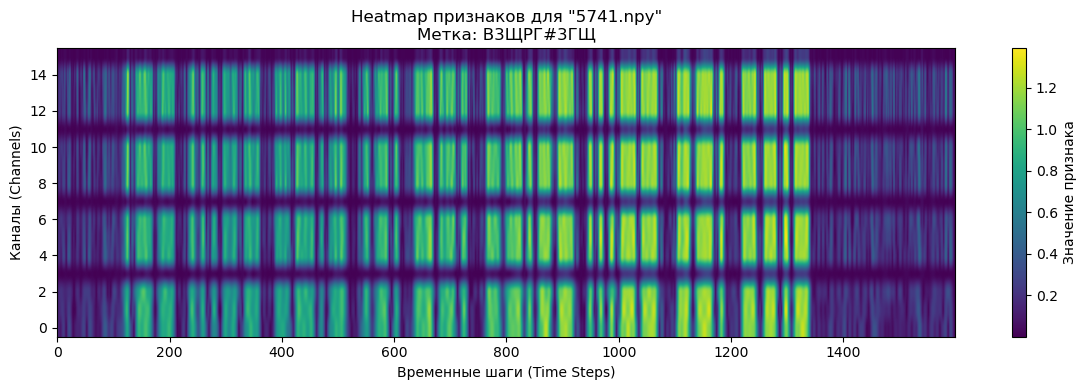

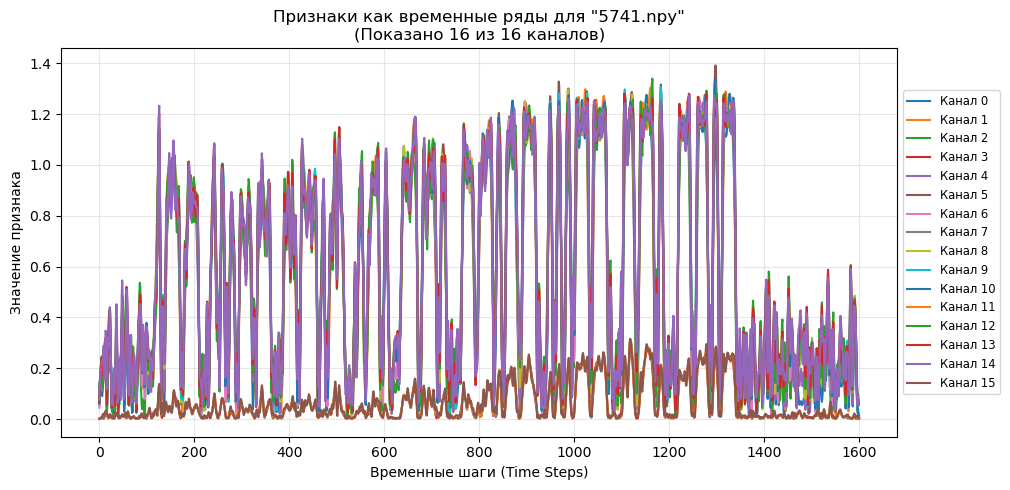


--- Пример 2/3: Визуализация файла '19928.npy' ---
    Метка: 'Б#ЧМТЗУА'
    Размерность данных: (16, 1600) (Каналы, Время)


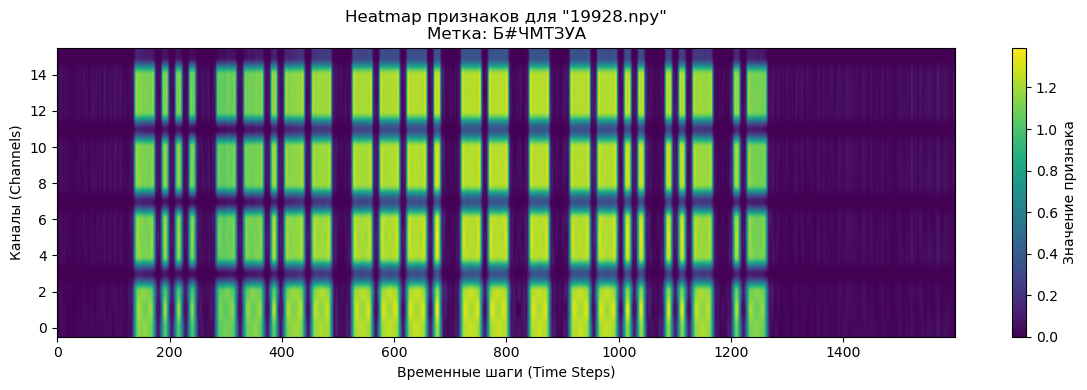

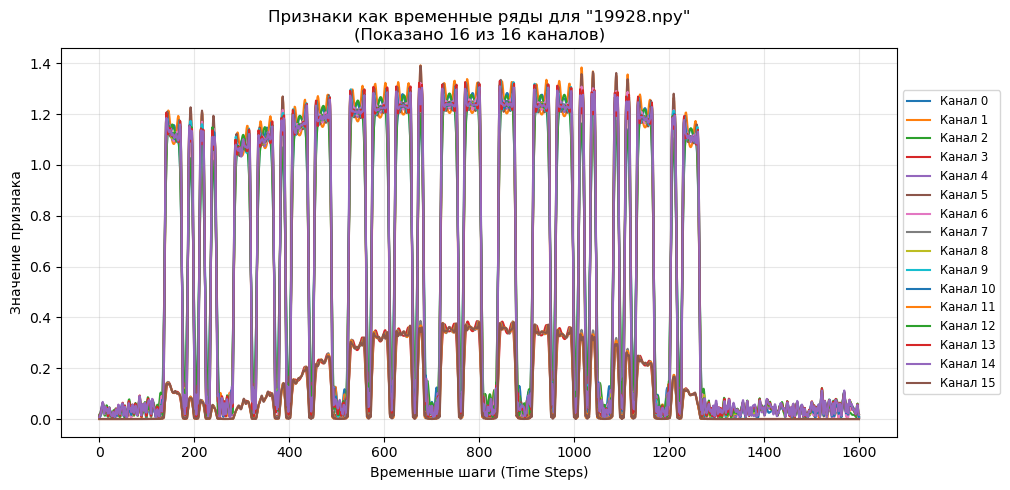


--- Пример 3/3: Визуализация файла '2555.npy' ---
    Метка: 'РКПЕВБ4 ПЗ'
    Размерность данных: (16, 1600) (Каналы, Время)


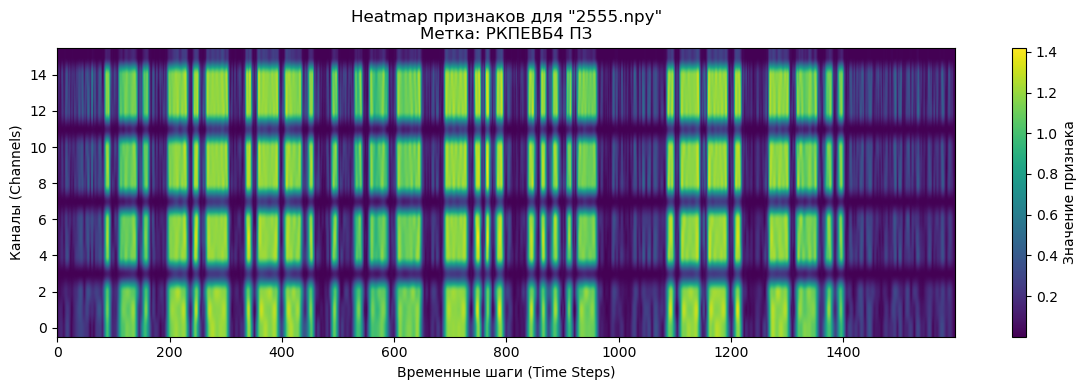

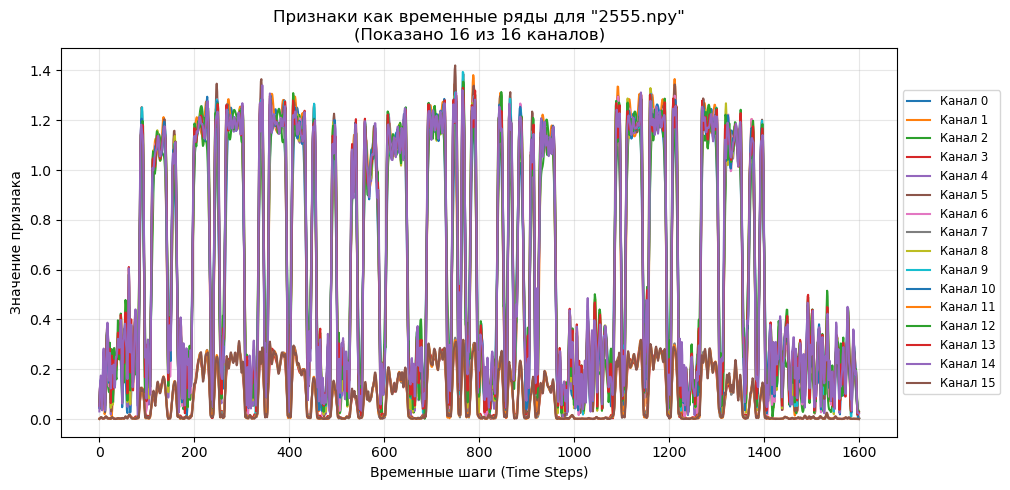

In [25]:
# Ячейка 11: Визуализация Признаков из `.npy` файла (ИСПРАВЛЕНО - независимая загрузка данных)

import random
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import pandas as pd # Добавили импорт pandas
import hydra # Добавили импорт hydra
from omegaconf import DictConfig, OmegaConf # Добавили импорт omegaconf

# --- Попытка загрузить функции из предыдущих ячеек ---
# Убедитесь, что ячейка с load_metadata (Ячейка 3) была выполнена
try:
    _ = load_metadata # Проверяем, доступна ли функция
except NameError:
    log.error("🛑 Ошибка: Функция load_metadata не найдена. Убедитесь, что Ячейка 3 была выполнена.")
    raise

# --- Параметры ---
num_samples_to_show = 3 # Сколько случайных примеров показать
CONFIG_PATH_RELATIVE = "conf" # Путь к папке с конфигом относительно ноутбука
CONFIG_NAME = "config"      # Имя основного файла конфига

# --- Загрузка конфигурации и данных (независимо) ---
df_full = pd.DataFrame() # Инициализируем пустым DataFrame
feature_dir_path = None
cfg = None

try:
    # Инициализируем Hydra (если еще не сделано) и загружаем конфиг
    if not hydra.core.global_hydra.GlobalHydra.instance().is_initialized():
        hydra.initialize(config_path=CONFIG_PATH_RELATIVE, version_base=None)
    cfg = hydra.compose(config_name=CONFIG_NAME)
    log.info(f"Конфигурация '{CONFIG_NAME}' загружена для визуализации.")

    # Получаем пути из конфига
    # Используем to_absolute_path для корректной работы с путями Hydra
    data_dir_path = Path(hydra.utils.to_absolute_path(cfg.paths.data_dir))
    feature_dir_path = Path(hydra.utils.to_absolute_path(cfg.paths.feature_dir))
    log.info(f"Папка данных: {data_dir_path}")
    log.info(f"Папка признаков: {feature_dir_path}")

    # Загружаем метаданные
    df_full = load_metadata(data_dir_path, cfg)

except hydra.errors.MissingConfigException as e:
     log.error(f"🛑 Ошибка Hydra: Не найден конфиг '{CONFIG_NAME}' в папке '{CONFIG_PATH_RELATIVE}'. {e}")
     raise
except FileNotFoundError as e:
     log.error(f"🛑 Ошибка: Не найден файл или папка, указанные в конфигурации. {e}")
     raise
except KeyError as e:
     log.error(f"🛑 Ошибка: Не найден ключ в конфигурации (возможно, paths.data_dir или paths.feature_dir). {e}")
     raise
except Exception as e:
     log.error(f"🛑 Неожиданная ошибка при загрузке конфигурации или данных: {e}", exc_info=True)
     raise

# --- Визуализация ---

if df_full.empty:
    log.error("🛑 Не удалось загрузить метаданные, визуализация невозможна.")
elif feature_dir_path is None:
    log.error("🛑 Не удалось определить путь к признакам (feature_dir_path), визуализация невозможна.")
else:
    log.info(f"Найдено {len(df_full)} записей в метаданных для сэмплирования.")
    for i in range(num_samples_to_show):
        # Выбираем случайный сэмпл из ПОЛНОГО датасета
        try:
            sample_row = df_full.sample(1).iloc[0]
            sample_id_raw = sample_row.get('id')
            sample_label = sample_row.get(cfg.data_params.label_column, "N/A") # Получаем метку
            if sample_id_raw is None:
                log.error("🛑 В выбранной строке отсутствует колонка 'id'.")
                continue
            base_filename = str(sample_id_raw).split('.')[0]
            feature_file = feature_dir_path / f"{base_filename}.npy"
        except Exception as e:
            log.error(f"🛑 Ошибка при выборе сэмпла или формировании пути: {e}")
            continue

        log.info(f"\n--- Пример {i+1}/{num_samples_to_show}: Визуализация файла '{feature_file.name}' ---")
        log.info(f"    Метка: '{sample_label}'")

        # Загружаем .npy файл
        try:
            features = np.load(feature_file)

            if features.ndim != 2:
                log.warning(f"⚠️ Файл '{feature_file.name}' имеет размерность {features.ndim}D, ожидалась 2D. Пропуск.")
                continue

            log.info(f"    Размерность данных: {features.shape} (Каналы, Время)")

            # --- Способ 1: Heatmap (Изображение) ---
            plt.figure(figsize=(12, 4))
            plt.imshow(features, aspect='auto', origin='lower', cmap='viridis')
            plt.colorbar(label='Значение признака')
            plt.xlabel('Временные шаги (Time Steps)')
            plt.ylabel('Каналы (Channels)')
            plt.title(f'Heatmap признаков для "{base_filename}.npy"\nМетка: {sample_label}')
            plt.tight_layout()
            plt.show()

            # --- Способ 2: Временные ряды (Линейные графики) ---
            num_channels, seq_len = features.shape
            plt.figure(figsize=(12, 5))

            max_channels_to_plot = 16
            channels_to_plot = range(min(num_channels, max_channels_to_plot))

            for channel_idx in channels_to_plot:
                plt.plot(features[channel_idx, :], label=f'Канал {channel_idx}')

            if num_channels > max_channels_to_plot:
                 plt.text(0.98, 0.02, f'... (+{num_channels - max_channels_to_plot} каналов)',
                          ha='right', va='bottom', transform=plt.gca().transAxes, fontsize=9, color='gray')

            plt.xlabel('Временные шаги (Time Steps)')
            plt.ylabel('Значение признака')
            plt.title(f'Признаки как временные ряды для "{base_filename}.npy"\n(Показано {len(channels_to_plot)} из {num_channels} каналов)')
            plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small')
            plt.grid(True, alpha=0.3)
            plt.tight_layout(rect=[0, 0, 0.85, 1])
            plt.show()

        except FileNotFoundError:
            log.error(f"🛑 Файл не найден: {feature_file}")
        except Exception as e:
            log.error(f"🛑 Не удалось загрузить или отобразить файл '{feature_file.name}': {e}", exc_info=True)